# Machine Learning-Based Network Intrusion Classification in IoT Environments Using the CICIoT2023 Dataset

**Course:** Machine Learning and Data Mining — IT9201  
**Programme:** Master of Science in Artificial Intelligence  
**Institution:** Bahrain Polytechnic  
**Lecturer:** Dr. Shomona Gracia Jacob  
**Student Name:* Enas Alsawaeer*  
**Student ID:* 12011215*  
**Submission Date:** 27 May 2026

---
## Table of Contents

1. [Libraries and Environment Setup](#1-libraries-and-environment-setup)
2. [Dataset Loading and Description](#2-dataset-loading-and-description)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Feature Selection](#5-feature-selection)
6. [Model Training](#6-model-training)
7. [Hyperparameter Optimization](#7-hyperparameter-optimization)
8. [Model Evaluation and Comparison](#8-model-evaluation-and-comparison)
9. [Critical Analysis and Discussion](#9-critical-analysis-and-discussion)

---
## 1. Libraries and Environment Setup

In [3]:
import os, csv, gc, time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

---
## 2. Dataset Loading and Description

In [4]:
RANDOM_STATE            = 42
BASE_FOLDER             = r"C:\Users\enas.alsawaeer\Documents\GitHub\MLandDM\CSV\CSV"
TEST_SIZE               = 0.20
CORR_THRESHOLD          = 0.85
RF_IMPORTANCE_THRESHOLD = 0.01
N_RF_TREES_FOR_SELECT   = 100
TUNE_ITERATIONS         = 10
TUNE_CV_FOLDS           = 3
TOP_N_IMPORTANCE        = 25   

In [5]:
CAP_BY_CLASS = {
    'DDoS'       : 500_000,
    'DoS'        : 500_000,
    'Mirai'      : 300_000,
    'Benign'     : 200_000,
    'Recon'      : 200_000,
    'Spoofing'   : 200_000,
    'WebAttack'  : None,
    'BruteForce' : None,
    'Malware'    : None,
    'Uploading'  : None,
}

In [6]:
SMOTE_TARGETS = {
    'WebAttack'  : 50_000,
    'BruteForce' : 50_000,
    'Malware'    : 10_000,
    'Uploading'  :  5_000,
}

In [7]:
FOLDERS = {
    "Benign_Final"            : "Benign",
    # DDoS (12 subtypes)
    "DDoS-SYN_Flood"          : "DDoS",
    "DDoS-UDP_Flood"          : "DDoS",
    "DDoS-HTTP_Flood"         : "DDoS",
    "DDoS-ICMP_Flood"         : "DDoS",
    "DDoS-TCP_Flood"          : "DDoS",
    "DDoS-RSTFINFLOOD"        : "DDoS",
    "DDoS-PSHACK_FLOOD"       : "DDoS",
    "DDoS-SlowLoris"          : "DDoS",
    "DDoS-SynonymousIP_Flood" : "DDoS",
    "DDoS-ACK_Fragmentation"  : "DDoS",
    "DDoS-ICMP_Fragmentation" : "DDoS",
    "DDoS-UDP_Fragmentation"  : "DDoS",
    # DoS (4)
    "DoS-HTTP_Flood"          : "DoS",
    "DoS-SYN_Flood"           : "DoS",
    "DoS-TCP_Flood"           : "DoS",
    "DoS-UDP_Flood"           : "DoS",
    # Mirai (3)
    "Mirai-greeth_flood"      : "Mirai",
    "Mirai-greip_flood"       : "Mirai",
    "Mirai-udpplain"          : "Mirai",
    # Recon (5)
    "Recon-HostDiscovery"     : "Recon",
    "Recon-OSScan"            : "Recon",
    "Recon-PingSweep"         : "Recon",
    "Recon-PortScan"          : "Recon",
    "VulnerabilityScan"       : "Recon",
    # Spoofing (2)
    "DNS_Spoofing"            : "Spoofing",
    "MITM-ArpSpoofing"        : "Spoofing",
    # Web attacks (4)
    "BrowserHijacking"        : "WebAttack",
    "CommandInjection"        : "WebAttack",
    "SqlInjection"            : "WebAttack",
    "XSS"                     : "WebAttack",
    # Single-subtype families
    "DictionaryBruteForce"    : "BruteForce",
    "Backdoor_Malware"        : "Malware",
    "Uploading_Attack"        : "Uploading",
}
 

In [8]:
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'savefig.dpi'     : 150,
    'savefig.bbox'    : 'tight',
})

In [9]:
def dataset_inventory(base_folder: str) -> int:
    """Print files / row count / size for every class folder."""
    print(f"\n{'Folder':<35} {'Files':>6} {'Rows':>12} {'MB':>8}")
    print("-" * 65)
    grand_total = 0
    for folder_name in sorted(os.listdir(base_folder)):
        folder_path = os.path.join(base_folder, folder_name)
        if not os.path.isdir(folder_path):
            continue
        files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
        total_rows = total_mb = 0
        for fname in files:
            fp = os.path.join(folder_path, fname)
            total_mb += os.path.getsize(fp) / (1024 * 1024)
            with open(fp, "r", encoding="utf-8", errors="ignore") as fh:
                total_rows += sum(1 for _ in fh) - 1
        grand_total += total_rows
        print(f"{folder_name:<35} {len(files):>6} {total_rows:>12,} {total_mb:>7.1f}")
    print("-" * 65)
    print(f"{'GRAND TOTAL':<35} {grand_total:>31,}")
    return grand_total

total_rows = dataset_inventory(BASE_FOLDER)


Folder                               Files         Rows       MB
-----------------------------------------------------------------
Backdoor_Malware                         1        3,218     0.6
Benign_Final                             4    1,098,191   216.9
BrowserHijacking                         1        5,859     1.2
CommandInjection                         1        5,409     1.1
DDoS-ACK_Fragmentation                  13      285,075    59.9
DDoS-HTTP_Flood                          1       28,790     6.2
DDoS-ICMP_Flood                         27    7,200,501  1264.8
DDoS-ICMP_Fragmentation                 20      452,490    95.1
DDoS-PSHACK_FLOOD                       16    4,094,772   733.9
DDoS-RSTFINFLOOD                        16    4,045,279   731.5
DDoS-SYN_Flood                          16    4,059,179   738.4
DDoS-SlowLoris                           1       23,426     5.0
DDoS-SynonymousIP_Flood                 14    3,598,133   643.4
DDoS-TCP_Flood                      

In [10]:
def validate_schema(base_folder: str, folders: dict) -> bool:
    """Confirm every CSV has identical column headers. Returns True if all match."""
    all_files = []
    for folder_name in folders:
        folder_path = os.path.join(base_folder, folder_name)
        if not os.path.isdir(folder_path):
            print(f"  WARNING - folder not found: {folder_name}")
            continue
        for fname in os.listdir(folder_path):
            if fname.endswith(".csv"):
                all_files.append(os.path.join(folder_path, fname))

    if not all_files:
        print("No CSV files found - check BASE_FOLDER.")
        return False

    with open(all_files[0], "r", encoding="utf-8", newline="") as f:
        ref_cols = next(csv.reader(f))
    print(f"Reference schema: {len(ref_cols)} columns  ({all_files[0].split(os.sep)[-2]})")

    mismatches = []
    for path in all_files[1:]:
        with open(path, "r", encoding="utf-8", newline="") as f:
            cur_cols = next(csv.reader(f))
        if cur_cols != ref_cols:
            mismatches.append((path, set(cur_cols) ^ set(ref_cols)))

    if mismatches:
        for path, diff in mismatches:
            print(f"  MISMATCH  {path}\n    diff: {diff}")
        return False

    print(f"Schema OK - all {len(all_files)} files match.")
    return True

validate_schema(BASE_FOLDER, FOLDERS)

Reference schema: 39 columns  (Benign_Final)
Schema OK - all 309 files match.


True

---
### 2.1 — Dataset Sampling Justification

The raw CICIoT2023 corpus contains approximately **8 million rows** across 34 attack
sub-folders. Loading the full dataset on a 32 GB RAM workstation is not feasible: the
in-memory DataFrame would require ~25–30 GB, leaving insufficient headroom for the
correlation matrix computation and train/test split copies.

**Per-class caps applied at load time:**

| Class | Cap | Rationale |
|---|---|---|
| DDoS | 500,000 | Largest family (12 sub-types); preserves sub-type diversity |
| DoS | 500,000 | Second-largest; same reasoning |
| Mirai | 300,000 | Three sub-types; 300k covers all adequately |
| Benign | 200,000 | Sufficient for a balanced binary split |
| Recon | 200,000 | Five sub-types; 200k representative |
| Spoofing | 200,000 | Two sub-types; 200k representative |
| WebAttack, BruteForce, Malware, Uploading | None (full) | Minority classes retained in full for SMOTE |

In [11]:
# Load all CSVs, label each row, apply per-class caps ────────────────
#
# Each sub-folder maps to one class label (defined in FOLDERS).
# Rows are labelled with label_multiclass and label_binary (0 = Benign, 1 = Attack).
# After loading, CAP_BY_CLASS sub-samples each class so the dataset fits in RAM.

print("Loading CSVs …")
t0   = time.time()
dfs  = []

for folder_name, class_label in FOLDERS.items():
    folder_path = os.path.join(BASE_FOLDER, folder_name)
    if not os.path.isdir(folder_path):
        print(f"  SKIP (not found): {folder_name}")
        continue
    files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    if not files:
        print(f"  SKIP (empty):     {folder_name}")
        continue
    sub = pd.concat(
        [pd.read_csv(os.path.join(folder_path, f), low_memory=False) for f in files],
        ignore_index=True,
    )
    sub["label_multiclass"] = class_label
    sub["label_binary"]     = 0 if class_label == "Benign" else 1
    dfs.append(sub)
    print(f"  {folder_name:<32}  ->  {class_label:<10}  {len(sub):>10,} rows")
    gc.collect()

data = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()
print(f"\nRaw shape after concat : {data.shape}  ({time.time() - t0:.0f}s)")

# Apply per-class caps
print("\nApplying per-class caps …")
capped = []
for label, group in data.groupby("label_multiclass", sort=False):
    cap = CAP_BY_CLASS.get(label)
    if cap is not None and len(group) > cap:
        group = group.sample(n=cap, random_state=RANDOM_STATE)
        note  = f"capped  -> {len(group):>10,}"
    else:
        note  = f"kept    -> {len(group):>10,}"
    print(f"  {label:<12}  {note}")
    capped.append(group)

data = pd.concat(capped, ignore_index=True)
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
del capped
gc.collect()

# float64 -> float32 to halve RAM usage
_fc = data.select_dtypes(include="float64").columns
data[_fc] = data[_fc].astype("float32")
del _fc

_mem = data.memory_usage(deep=True).sum() / 1e9
print(f"\nFinal shape  : {data.shape}")
print(f"Memory usage : {_mem:.2f} GB")

Loading CSVs …
  Benign_Final                      ->  Benign       1,098,191 rows
  DDoS-SYN_Flood                    ->  DDoS         4,059,179 rows
  DDoS-UDP_Flood                    ->  DDoS         5,412,231 rows
  DDoS-HTTP_Flood                   ->  DDoS            28,790 rows
  DDoS-ICMP_Flood                   ->  DDoS         7,200,501 rows
  DDoS-TCP_Flood                    ->  DDoS         4,497,649 rows
  DDoS-RSTFINFLOOD                  ->  DDoS         4,045,279 rows
  DDoS-PSHACK_FLOOD                 ->  DDoS         4,094,772 rows
  DDoS-SlowLoris                    ->  DDoS            23,426 rows
  DDoS-SynonymousIP_Flood           ->  DDoS         3,598,133 rows
  DDoS-ACK_Fragmentation            ->  DDoS           285,075 rows
  DDoS-ICMP_Fragmentation           ->  DDoS           452,490 rows
  DDoS-UDP_Fragmentation            ->  DDoS           286,925 rows
  DoS-HTTP_Flood                    ->  DoS             71,861 rows
  DoS-SYN_Flood                  

---
## 3. Exploratory Data Analysis (EDA)

In [12]:
data.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,label_multiclass,label_binary
0,21.2000,6,156.9000,10.9130,0.0000,0.2000,0.0000,0.3000,0.4000,0.0000,...,60.0000,230.0000,132.3000,72.5458,132.3000,0.0983,10.0000,5262.8999,Recon,1
1,20.0000,6,64.0000,9192.7939,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,60.0000,60.0000,60.0000,0.0000,60.0000,0.0001,100.0000,0.0000,DoS,1
2,8.0000,17,64.0000,6375.9692,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,60.0000,60.0000,60.0000,0.0000,60.0000,0.0002,100.0000,0.0000,DoS,1
3,24.8000,6,208.5000,655.9955,0.0000,0.0000,0.0000,0.3000,0.7000,0.0000,...,60.0000,214.0000,103.5000,61.4948,103.5000,0.0022,10.0000,3781.6111,Benign,0
4,28.8000,6,72.2000,80.0134,0.0000,0.0000,0.0000,0.5000,0.9000,0.0000,...,60.0000,1279.0000,330.7000,489.8476,330.7000,0.0125,10.0000,239950.6719,Recon,1


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1937893 entries, 0 to 1937892
Data columns (total 41 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Header_Length     float32
 1   Protocol Type     int64  
 2   Time_To_Live      float32
 3   Rate              float32
 4   fin_flag_number   float32
 5   syn_flag_number   float32
 6   rst_flag_number   float32
 7   psh_flag_number   float32
 8   ack_flag_number   float32
 9   ece_flag_number   float32
 10  cwr_flag_number   float32
 11  ack_count         float32
 12  syn_count         float32
 13  fin_count         float32
 14  rst_count         float32
 15  HTTP              float32
 16  HTTPS             float32
 17  DNS               float32
 18  Telnet            float32
 19  SMTP              float32
 20  SSH               float32
 21  IRC               float32
 22  TCP               float32
 23  UDP               float32
 24  DHCP              float32
 25  ARP               float32
 26  ICMP          

In [14]:
data.dtypes

Header_Length       float32
Protocol Type         int64
Time_To_Live        float32
Rate                float32
fin_flag_number     float32
syn_flag_number     float32
rst_flag_number     float32
psh_flag_number     float32
ack_flag_number     float32
ece_flag_number     float32
cwr_flag_number     float32
ack_count           float32
syn_count           float32
fin_count           float32
rst_count           float32
HTTP                float32
HTTPS               float32
DNS                 float32
Telnet              float32
SMTP                float32
SSH                 float32
IRC                 float32
TCP                 float32
UDP                 float32
DHCP                float32
ARP                 float32
ICMP                float32
IGMP                float32
IPv                 float32
LLC                 float32
Tot sum             float32
Min                 float32
Max                 float32
AVG                 float32
Std                 float32
Tot size            

In [15]:
data.shape

(1937893, 41)

In [16]:
data['label_binary'].unique()

array([1, 0], dtype=int64)

In [17]:
data['label_binary'].value_counts()

label_binary
1    1737893
0     200000
Name: count, dtype: int64

In [18]:
data['label_multiclass'].unique()

array(['Recon', 'DoS', 'Benign', 'DDoS', 'Mirai', 'Spoofing', 'WebAttack',
       'BruteForce', 'Malware', 'Uploading'], dtype=object)

In [19]:
data['label_multiclass'].value_counts()

label_multiclass
DoS           500000
DDoS          500000
Mirai         300000
Recon         200000
Benign        200000
Spoofing      200000
WebAttack      20359
BruteForce     13064
Malware         3218
Uploading       1252
Name: count, dtype: int64

In [20]:
data.isna().sum()

Header_Length        0
Protocol Type        0
Time_To_Live         0
Rate                 0
fin_flag_number      0
syn_flag_number      0
rst_flag_number      0
psh_flag_number      0
ack_flag_number      0
ece_flag_number      0
cwr_flag_number      0
ack_count            0
syn_count            0
fin_count            0
rst_count            0
HTTP                 0
HTTPS                0
DNS                  0
Telnet               0
SMTP                 0
SSH                  0
IRC                  0
TCP                  0
UDP                  0
DHCP                 0
ARP                  0
ICMP                 0
IGMP                 0
IPv                  0
LLC                  0
Tot sum              0
Min                  0
Max                  0
AVG                  0
Std                 60
Tot size             0
IAT                  0
Number               0
Variance            60
label_multiclass     0
label_binary         0
dtype: int64

In [21]:
data.notna().sum() 

Header_Length       1937893
Protocol Type       1937893
Time_To_Live        1937893
Rate                1937893
fin_flag_number     1937893
syn_flag_number     1937893
rst_flag_number     1937893
psh_flag_number     1937893
ack_flag_number     1937893
ece_flag_number     1937893
cwr_flag_number     1937893
ack_count           1937893
syn_count           1937893
fin_count           1937893
rst_count           1937893
HTTP                1937893
HTTPS               1937893
DNS                 1937893
Telnet              1937893
SMTP                1937893
SSH                 1937893
IRC                 1937893
TCP                 1937893
UDP                 1937893
DHCP                1937893
ARP                 1937893
ICMP                1937893
IGMP                1937893
IPv                 1937893
LLC                 1937893
Tot sum             1937893
Min                 1937893
Max                 1937893
AVG                 1937893
Std                 1937833
Tot size            

In [22]:
data.describe()

C:\Users\enas.alsawaeer\.conda\envs\gpu_env\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,label_binary
count,1937893.0000,1937893.0000,1937893.0000,1937893.0000,1937893.0000,1937893.0000,1937893.0000,1937893.0000,1937893.0000,1937893.0000,...,1937893.0000,1937893.0000,1937893.0000,1937893.0000,1937833.0000,1937893.0000,1937893.0000,1937893.0000,1937833.0000,1937893.0000
mean,16.0285,12.6680,77.1116,inf,0.0370,0.1411,0.0443,0.0886,0.2628,0.0002,...,14480.4199,124.9435,546.9066,282.8867,138.6352,282.8867,0.0240,70.3036,135634.4062,0.8968
std,10.4139,12.5966,32.5825,NaN,0.1735,0.3295,0.1901,0.2071,0.3892,0.0058,...,20138.2754,216.8557,1024.5770,398.6873,341.1960,398.6873,18.3373,42.2988,820246.6250,0.3042
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,60.0000,42.0000,46.0000,46.0000,0.0000,46.0000,-0.0065,1.0000,0.0000,0.0000
25%,8.0000,6.0000,64.0000,802.5625,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,6000.0000,60.0000,60.0000,60.0000,0.0000,60.0000,0.0000,10.0000,0.0000,1.0000
50%,20.0000,6.0000,64.0000,8765.8916,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,6000.0000,60.0000,156.0000,66.0000,0.8442,66.0000,0.0001,100.0000,0.7127,1.0000
75%,20.2400,17.0000,69.4000,26581.5586,0.0000,0.0000,0.0000,0.1000,0.6000,0.0000,...,9721.0000,66.0000,578.0000,539.6300,74.4703,539.6300,0.0014,100.0000,5545.8223,1.0000
max,60.0000,47.0000,255.0000,inf,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,...,267565.0000,4895.0000,37714.0000,7016.3999,9730.1797,7016.3999,24767.9961,100.0000,94676392.0000,1.0000


In [23]:
data.shape

(1937893, 41)

In [24]:
numeric_data = data.select_dtypes(include="number")

In [25]:
for col in data.columns:
    non_numeric = pd.to_numeric(data[col], errors="coerce").isna().sum() - data[col].isna().sum()
    print(col, "->", non_numeric)

Header_Length -> 0
Protocol Type -> 0
Time_To_Live -> 0
Rate -> 0
fin_flag_number -> 0
syn_flag_number -> 0
rst_flag_number -> 0
psh_flag_number -> 0
ack_flag_number -> 0
ece_flag_number -> 0
cwr_flag_number -> 0
ack_count -> 0
syn_count -> 0
fin_count -> 0
rst_count -> 0
HTTP -> 0
HTTPS -> 0
DNS -> 0
Telnet -> 0
SMTP -> 0
SSH -> 0
IRC -> 0
TCP -> 0
UDP -> 0
DHCP -> 0
ARP -> 0
ICMP -> 0
IGMP -> 0
IPv -> 0
LLC -> 0
Tot sum -> 0
Min -> 0
Max -> 0
AVG -> 0
Std -> 0
Tot size -> 0
IAT -> 0
Number -> 0
Variance -> 0
label_multiclass -> 1937893
label_binary -> 0


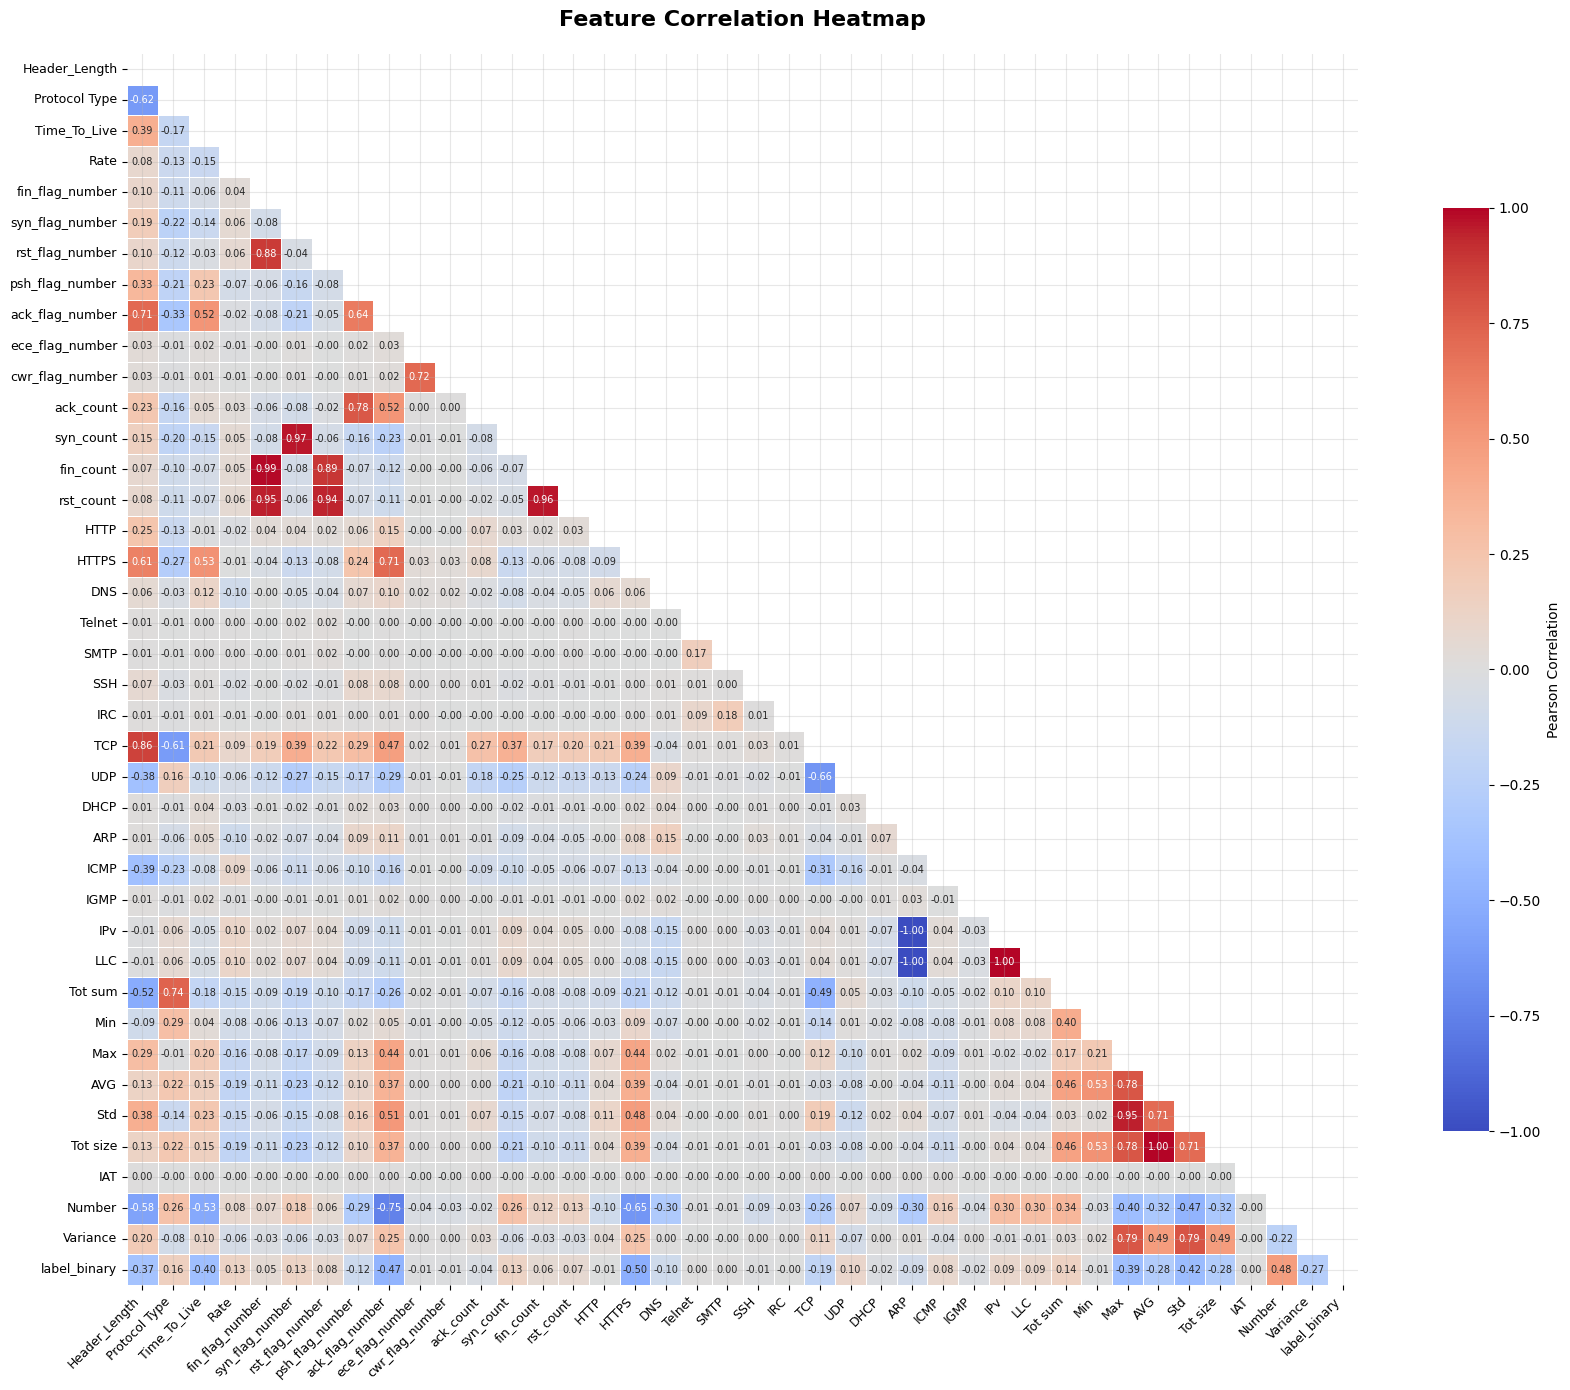

In [26]:
corr_matrix = numeric_data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    mask=mask,                  
    annot=True,                 
    fmt=".2f",                  
    cmap="coolwarm",            
    center=0,                  
    vmin=-1, vmax=1,
    linewidths=0.4,             
    linecolor='white',
    square=True,                
    cbar_kws={"shrink": 0.75, "label": "Pearson Correlation"},
    annot_kws={"size": 7},       
    ax=ax
)

ax.set_title("Feature Correlation Heatmap",
             fontsize=16, fontweight='bold', pad=20)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

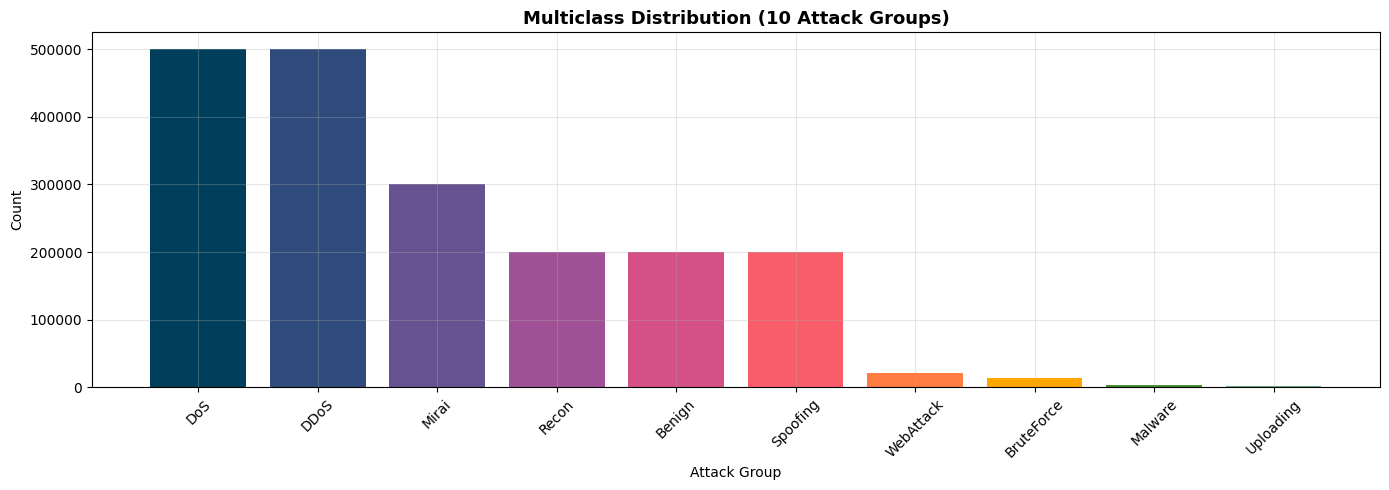

In [27]:
counts = data["label_multiclass"].value_counts()

colors = [
    "#003f5c", "#2f4b7c", "#665191", "#a05195",
    "#d45087", "#f95d6a", "#ff7c43", "#ffa600",
    "#488f31", "#6ab187"
]

plt.figure(figsize=(14, 5))
plt.bar(counts.index, counts.values, color=colors[:len(counts)])
plt.title("Multiclass Distribution (10 Attack Groups)")
plt.xlabel("Attack Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

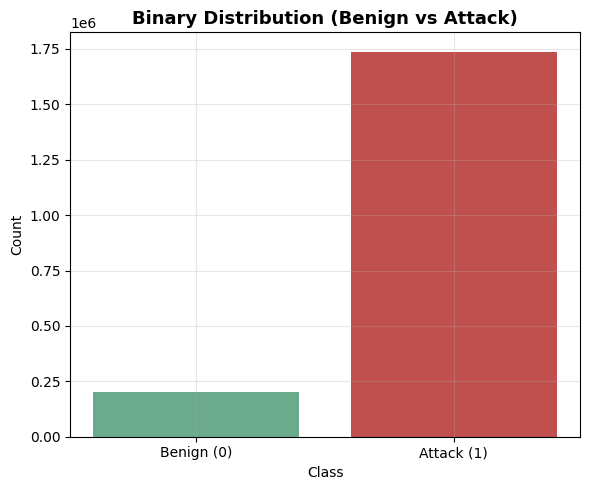

In [28]:
counts = data["label_binary"].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(["Benign (0)", "Attack (1)"], counts.values, color=["#6aab8e", "#c0504d"])
plt.title("Binary Distribution (Benign vs Attack)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

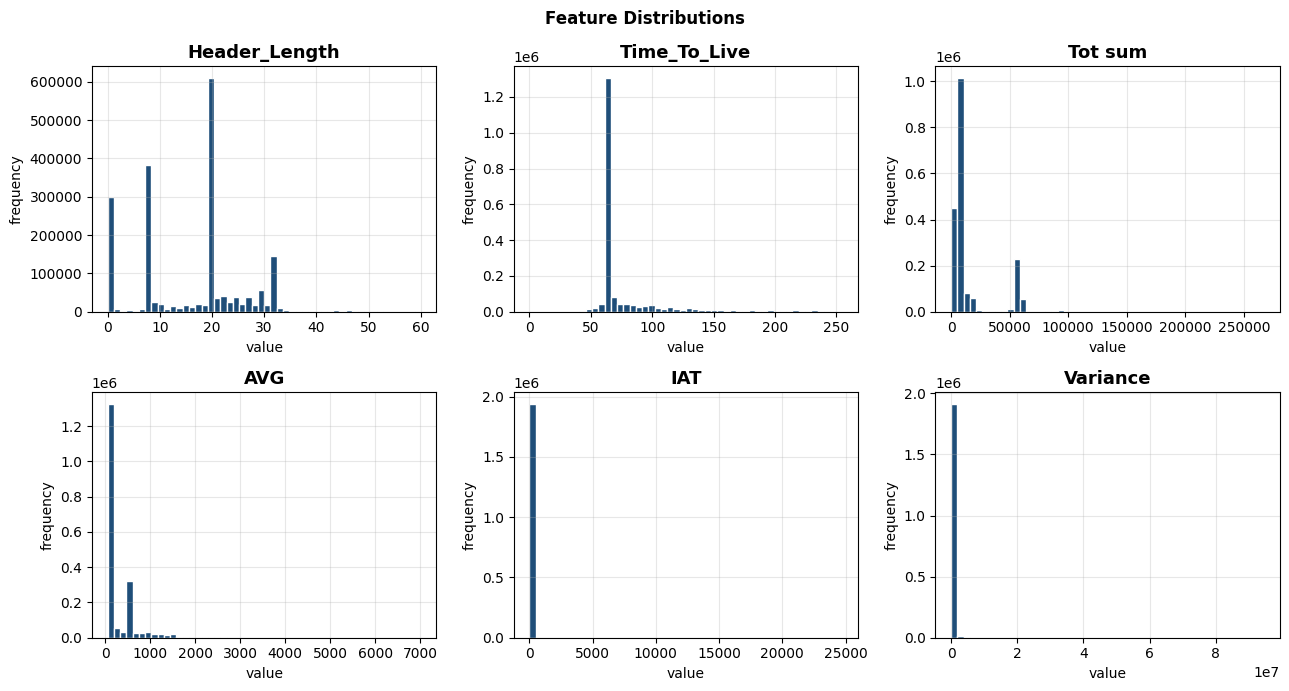

In [72]:
feats = ["Header_Length", "Time_To_Live", "Tot sum", "AVG", "IAT", "Variance"]
df_clean = data.replace([np.inf, -np.inf], np.nan).dropna(subset=feats)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, f in zip(axes.ravel(), feats):
    ax.hist(df_clean[f], bins=50, color="#1F4E79", edgecolor="white")
    ax.set_title(f); ax.set_xlabel("value"); ax.set_ylabel("frequency")
plt.suptitle("Feature Distributions", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=200, bbox_inches="tight")

In [29]:
folders = sorted(os.listdir(BASE_FOLDER))

print(f"{'Folder':<35} {'Files':>6} {'Total Rows':>15} {'Size MB':>10}")
print("=" * 70)

grand_total = 0
for folder_name in folders:
    folder_path = os.path.join(BASE_FOLDER, folder_name)
    if not os.path.isdir(folder_path):
        continue

    files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

    total_rows = 0
    total_size = 0
    for f in files:
        fp = os.path.join(folder_path, f)
        total_size += os.path.getsize(fp) / (1024*1024)
        with open(fp, "r", encoding="utf-8", errors="ignore") as file:
            total_rows += sum(1 for _ in file) - 1

    grand_total += total_rows
    print(f"{folder_name:<35} {len(files):>6} {total_rows:>15,} {total_size:>9.1f}")

print("=" * 70)
print(f"{'TOTAL':<35} {grand_total:>36,}")

Folder                               Files      Total Rows    Size MB
Backdoor_Malware                         1           3,218       0.6
Benign_Final                             4       1,098,191     216.9
BrowserHijacking                         1           5,859       1.2
CommandInjection                         1           5,409       1.1
DDoS-ACK_Fragmentation                  13         285,075      59.9
DDoS-HTTP_Flood                          1          28,790       6.2
DDoS-ICMP_Flood                         27       7,200,501    1264.8
DDoS-ICMP_Fragmentation                 20         452,490      95.1
DDoS-PSHACK_FLOOD                       16       4,094,772     733.9
DDoS-RSTFINFLOOD                        16       4,045,279     731.5
DDoS-SYN_Flood                          16       4,059,179     738.4
DDoS-SlowLoris                           1          23,426       5.0
DDoS-SynonymousIP_Flood                 14       3,598,133     643.4
DDoS-TCP_Flood                   

---
## 4. Data Preprocessing

### Step 1 - Handle Missing Values and Infinity

In [30]:
LABEL_COLS   = ['label_binary', 'label_multiclass']
numeric_cols = [c for c in data.select_dtypes(include='number').columns
                if c not in LABEL_COLS]

n_inf = np.isinf(data[numeric_cols].values).sum()
n_nan = data[numeric_cols].isna().sum().sum()
print(f"Before cleaning - Inf: {n_inf:,}   NaN: {n_nan:,}")

data[numeric_cols] = data[numeric_cols].replace([np.inf, -np.inf], np.nan)
col_medians        = data[numeric_cols].median()
data[numeric_cols] = data[numeric_cols].fillna(col_medians)

print(f"After  cleaning - Inf: {np.isinf(data[numeric_cols].values).sum()}   "
      f"NaN: {data[numeric_cols].isna().sum().sum()}")

Before cleaning - Inf: 72   NaN: 120
After  cleaning - Inf: 0   NaN: 0


### Step 2 - Correlation-Based Feature Selection

Explore different correlation thresholds to identify the best cutoff.

In [31]:
corr_matrix = data[numeric_cols].corr()

print("Correlation threshold scan (pairs above threshold):")
for t in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    upper  = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    n_high = int((upper.abs() > t).sum().sum())
    marker = "  <-- selected" if t == CORR_THRESHOLD else ""
    print(f"  threshold = {t:.2f}  ->  {n_high:4d} pairs{marker}")

Correlation threshold scan (pairs above threshold):
  threshold = 0.70  ->    25 pairs
  threshold = 0.75  ->    18 pairs
  threshold = 0.80  ->    13 pairs
  threshold = 0.85  ->    13 pairs  <-- selected
  threshold = 0.90  ->    10 pairs
  threshold = 0.95  ->     7 pairs


In [32]:
# Drop ONE feature per highly-correlated pair (keep the first of each pair).
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop: set = set()
for col in upper.columns:
    if col in to_drop:
        continue
    high_corr = upper.index[upper[col].abs() > CORR_THRESHOLD].tolist()
    to_drop.update(high_corr)

feature_cols = [c for c in numeric_cols if c not in to_drop]
print(f"Dropped {len(to_drop)} features at threshold {CORR_THRESHOLD}")
print(f"Remaining features: {len(feature_cols)}")

# Materialise the reduced dataset so the train/test split cell can reference it
keep_cols    = feature_cols + ['label_binary', 'label_multiclass']
data_reduced = data[keep_cols].reset_index(drop=True)
print(f"data_reduced shape : {data_reduced.shape}")

Dropped 9 features at threshold 0.85
Remaining features: 30
data_reduced shape : (1937893, 32)


### Step 3 - Train / Test Split and Feature Scaling

In [33]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in data_reduced.columns
                if c not in ['label_binary', 'label_multiclass']]

X            = data_reduced[feature_cols].reset_index(drop=True)
y_binary     = data_reduced['label_binary'].reset_index(drop=True)
y_multiclass = data_reduced['label_multiclass'].reset_index(drop=True)

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_binary, y_multiclass,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass    # ensures proportional class split
)

print(f"Train set : {X_train.shape[0]:,} rows  |  {X_train.shape[1]} features")
print(f"Test set  : {X_test.shape[0]:,} rows  |  {X_test.shape[1]} features")
print()
print("Train — Multiclass distribution:")
print(y_train_multi.value_counts().to_string())
print()
print("Train — Binary distribution:")
print(y_train_bin.value_counts().to_string())

Train set : 1,550,314 rows  |  30 features
Test set  : 387,579 rows  |  30 features

Train — Multiclass distribution:
label_multiclass
DDoS          400000
DoS           400000
Mirai         240000
Benign        160000
Spoofing      160000
Recon         160000
WebAttack      16287
BruteForce     10451
Malware         2574
Uploading       1002

Train — Binary distribution:
label_binary
1    1390314
0     160000


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols
)

print("StandardScaler applied — fit on training set only.")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")

StandardScaler applied — fit on training set only.
X_train_scaled shape : (1550314, 30)
X_test_scaled shape  : (387579, 30)


In [35]:
# Binary model helper
# Trains 4 classifiers for binary (Benign vs Attack) classification.
# Called once per stage so the same code isn't repeated three times.
# Returns dict: { model_name: {y_pred, acc, f1, prec, rec, time} }

def run_binary_models(X_tr, y_tr, X_te, y_te, stage_label):
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, solver='saga', n_jobs=-1, random_state=RANDOM_STATE),
        'Random Forest'      : RandomForestClassifier(
            n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
        'XGBoost'            : XGBClassifier(
            n_estimators=100, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1),
        'LightGBM'           : LGBMClassifier(
            n_estimators=100, random_state=RANDOM_STATE,
            n_jobs=-1, verbose=-1),
    }

    results = {}
    print('=' * 62)
    print(f'BINARY — {stage_label}')
    print('=' * 62)
    print(f'  Train : {X_tr.shape}  |  class dist: '
          f'{dict(pd.Series(y_tr).value_counts().sort_index())}')
    print(f'  Test  : {X_te.shape}')

    for name, model in models.items():
        t0 = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - t0

        y_pred = model.predict(X_te)
        acc    = accuracy_score(y_te, y_pred)
        f1     = f1_score(y_te, y_pred, average='weighted', zero_division=0)
        prec   = precision_score(y_te, y_pred, average='weighted', zero_division=0)
        rec    = recall_score(y_te, y_pred, average='weighted', zero_division=0)

        results[name] = {
            'y_pred': y_pred,
            'acc'   : round(acc,  4),
            'f1'    : round(f1,   4),
            'prec'  : round(prec, 4),
            'rec'   : round(rec,  4),
            'time'  : round(elapsed, 1),
        }
        print(f"  {name:<25}  Acc={acc:.4f}  F1={f1:.4f}  ({elapsed:.1f}s)")

    print(f'\n{stage_label} — done.')
    return results

print("Binary Models helper ready.")

Binary Models helper ready.


---
### Stage 1 — Baseline (No SMOTE, All Features)


In [36]:
# Baseline : Train on the original scaled training set.

stage1_bin_results = run_binary_models(
    X_train_scaled, y_train_bin,
    X_test_scaled,  y_test_bin,
    stage_label="Stage 1 — Baseline (No SMOTE, All Features)",
)

# Summary table
_rows = [
    {'Model': n, 'Accuracy': r['acc'], 'Precision': r['prec'],
     'Recall': r['rec'], 'F1-Score': r['f1'], 'Time (s)': r['time']}
    for n, r in stage1_bin_results.items()
]
df_stage1_bin = pd.DataFrame(_rows).set_index('Model')
print(f"\nStage 1 Summary:\n{df_stage1_bin.to_string()}")
del _rows

BINARY — Stage 1 — Baseline (No SMOTE, All Features)
  Train : (1550314, 30)  |  class dist: {0: 160000, 1: 1390314}
  Test  : (387579, 30)
  Logistic Regression        Acc=0.9130  F1=0.9062  (838.2s)
  Random Forest              Acc=0.9532  F1=0.9524  (17.6s)
  XGBoost                    Acc=0.9511  F1=0.9506  (2.5s)
  LightGBM                   Acc=0.9495  F1=0.9489  (1.6s)

Stage 1 — Baseline (No SMOTE, All Features) — done.

Stage 1 Summary:
                     Accuracy  Precision  Recall  F1-Score  Time (s)
Model                                                               
Logistic Regression    0.9130     0.9031  0.9130    0.9062  838.2000
Random Forest          0.9532     0.9519  0.9532    0.9524   17.6000
XGBoost                0.9511     0.9502  0.9511    0.9506    2.5000
LightGBM               0.9495     0.9484  0.9495    0.9489    1.6000


### Step 4 - Handling Class Imbalance (SMOTE on Training Set Only)

In [37]:
print("Class counts BEFORE SMOTE:")
for cls, cnt in y_train_multi.value_counts().items():
    print(f"  {cls:<12} {cnt:>10,}")

smote = SMOTE(
    sampling_strategy=SMOTE_TARGETS,
    random_state=RANDOM_STATE,
    k_neighbors=3    # low k because Malware/Uploading have very few real samples
)
X_resampled_arr, y_train_multi_resampled = smote.fit_resample(X_train_scaled, y_train_multi)

X_train_resampled       = pd.DataFrame(X_resampled_arr, columns=feature_cols)
y_train_multi_resampled = pd.Series(y_train_multi_resampled).reset_index(drop=True)
y_train_bin_resampled   = (y_train_multi_resampled != 'Benign').astype(int)
del X_resampled_arr
gc.collect()

print("\nClass counts AFTER SMOTE:")
for cls, cnt in y_train_multi_resampled.value_counts().items():
    print(f"  {cls:<12} {cnt:>10,}")

Class counts BEFORE SMOTE:
  DDoS            400,000
  DoS             400,000
  Mirai           240,000
  Benign          160,000
  Spoofing        160,000
  Recon           160,000
  WebAttack        16,287
  BruteForce       10,451
  Malware           2,574
  Uploading         1,002

Class counts AFTER SMOTE:
  DDoS            400,000
  DoS             400,000
  Mirai           240,000
  Benign          160,000
  Spoofing        160,000
  Recon           160,000
  BruteForce       50,000
  WebAttack        50,000
  Malware          10,000
  Uploading         5,000


In [38]:
# Rebuild binary labels to match the resampled multiclass training set
y_train_bin_resampled = y_train_multi_resampled.map(
    lambda x: 0 if x == 'Benign' else 1
).reset_index(drop=True)

print('After SMOTE - Final Training Distribution:')
print()
print('  Multiclass:')
print(y_train_multi_resampled.value_counts().to_string())
print()
print('  Binary:')
print(y_train_bin_resampled.value_counts().to_string())
print()
print(f'X_train_resampled shape : {X_train_resampled.shape}')
print(f'X_test_scaled shape     : {X_test_scaled.shape}')

After SMOTE - Final Training Distribution:

  Multiclass:
label_multiclass
DDoS          400000
DoS           400000
Mirai         240000
Benign        160000
Spoofing      160000
Recon         160000
BruteForce     50000
WebAttack      50000
Malware        10000
Uploading       5000

  Binary:
label_multiclass
1    1475000
0     160000

X_train_resampled shape : (1635000, 30)
X_test_scaled shape     : (387579, 30)


---
### Stage 2 — After SMOTE (All Features)


In [39]:
# After SMOTE — resampled training, all features
# Uses X_train_resampled (SMOTE-balanced) with ALL features.
# Compares vs Stage 1 to isolate the effect of SMOTE alone.

stage2_bin_results = run_binary_models(
    X_train_resampled, y_train_bin_resampled,
    X_test_scaled,     y_test_bin,
    stage_label="Stage 2 — After SMOTE (All Features)",
)

# Summary table
_rows = [
    {'Model': n, 'Accuracy': r['acc'], 'Precision': r['prec'],
     'Recall': r['rec'], 'F1-Score': r['f1'], 'Time (s)': r['time']}
    for n, r in stage2_bin_results.items()
]
df_stage2_bin = pd.DataFrame(_rows).set_index('Model')
print(f"\nStage 2 Summary:\n{df_stage2_bin.to_string()}")

# Quick Stage 1 vs Stage 2 delta
print("\nDelta F1  (Stage 2 − Stage 1):")
for name in df_stage2_bin.index:
    d = df_stage2_bin.loc[name, 'F1-Score'] - df_stage1_bin.loc[name, 'F1-Score']
    arrow = "▲" if d >= 0 else "▼"
    print(f"  {name:<25}  {arrow}  {d:+.4f}")
del _rows

BINARY — Stage 2 — After SMOTE (All Features)
  Train : (1635000, 30)  |  class dist: {0: 160000, 1: 1475000}
  Test  : (387579, 30)
  Logistic Regression        Acc=0.9133  F1=0.9016  (874.1s)
  Random Forest              Acc=0.9531  F1=0.9519  (19.2s)
  XGBoost                    Acc=0.9505  F1=0.9493  (2.4s)
  LightGBM                   Acc=0.9489  F1=0.9473  (2.2s)

Stage 2 — After SMOTE (All Features) — done.

Stage 2 Summary:
                     Accuracy  Precision  Recall  F1-Score  Time (s)
Model                                                               
Logistic Regression    0.9133     0.9000  0.9133    0.9016  874.1000
Random Forest          0.9531     0.9513  0.9531    0.9519   19.2000
XGBoost                0.9505     0.9486  0.9505    0.9493    2.4000
LightGBM               0.9489     0.9466  0.9489    0.9473    2.2000

Delta F1  (Stage 2 − Stage 1):
  Logistic Regression        ▼  -0.0046
  Random Forest              ▼  -0.0005
  XGBoost                    ▼  -0.001

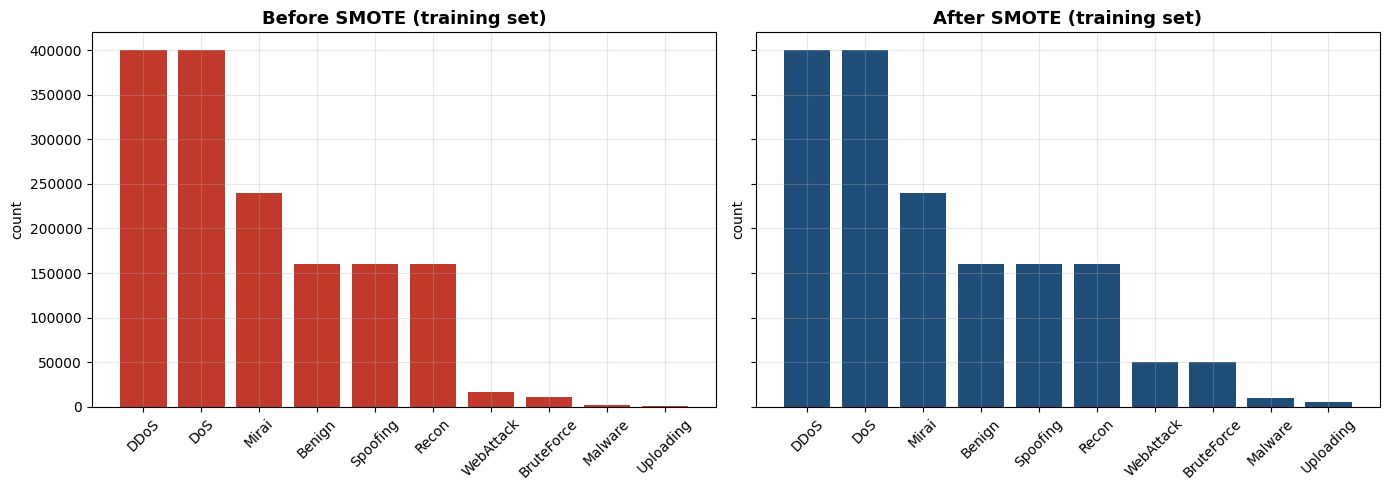

In [77]:
from collections import Counter
import matplotlib.pyplot as plt

before, after = Counter(y_train_multi), Counter(y_train_multi_resampled)
order = [c for c, _ in sorted(before.items(), key=lambda kv: -kv[1])]   

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
ax[0].bar(order, [before[c] for c in order], color="#C0392B"); ax[0].set_title("Before SMOTE (training set)")
ax[1].bar(order, [after[c]  for c in order], color="#1F4E79"); ax[1].set_title("After SMOTE (training set)")
for a in ax:
    a.tick_params(axis="x", rotation=45); a.set_ylabel("count")
plt.tight_layout()
plt.savefig("smote_before_after_multiclass.png", dpi=200, bbox_inches="tight")
plt.show()

In [78]:
# Binary 
smote_bin = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)
X_train_bin_res, y_train_bin_res = smote_bin.fit_resample(X_train_scaled, y_train_bin)

print("Before:", dict(Counter(y_train_bin))) 
print("After :", dict(Counter(y_train_bin_res)))

Before: {1: 1390314, 0: 160000}
After : {1: 1390314, 0: 695157}


---
## 5. Feature Selection

Rank features by importance using a Random Forest trained on resampled training data, then retain only features with importance > 1%.

Fitting feature-selection RF (100 trees)...
Done (34s)


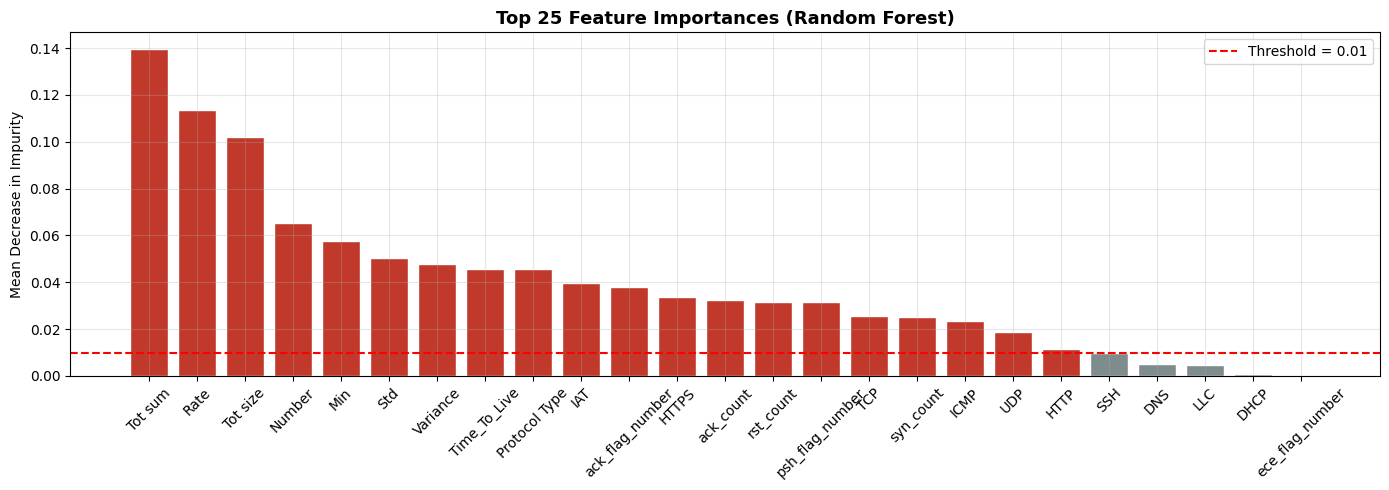


Selected 20 / 30 features (threshold = 0.01):
['Tot sum', 'Rate', 'Tot size', 'Number', 'Min', 'Std', 'Variance', 'Time_To_Live', 'Protocol Type', 'IAT', 'ack_flag_number', 'HTTPS', 'ack_count', 'rst_count', 'psh_flag_number', 'TCP', 'syn_count', 'ICMP', 'UDP', 'HTTP']


In [40]:
print(f"Fitting feature-selection RF ({N_RF_TREES_FOR_SELECT} trees)...")
t0          = time.time()
rf_selector = RandomForestClassifier(
    n_estimators=N_RF_TREES_FOR_SELECT,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_selector.fit(X_train_resampled, y_train_multi_resampled)
print(f"Done ({time.time() - t0:.0f}s)")

importance = pd.Series(
    rf_selector.feature_importances_, index=feature_cols
).sort_values(ascending=False)

# Plot top-N only for readability; red = above threshold, grey = below
top_imp = importance.head(TOP_N_IMPORTANCE)
colors  = ['#c0392b' if v > RF_IMPORTANCE_THRESHOLD else '#7f8c8d'
           for v in top_imp.values]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(top_imp.index, top_imp.values, color=colors, edgecolor='white')
ax.axhline(RF_IMPORTANCE_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold = {RF_IMPORTANCE_THRESHOLD}')
ax.set_title(f'Top {TOP_N_IMPORTANCE} Feature Importances (Random Forest)')
ax.set_ylabel('Mean Decrease in Impurity')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

selected_features = importance[importance > RF_IMPORTANCE_THRESHOLD].index.tolist()
X_train_final     = X_train_resampled[selected_features]
X_test_final      = X_test_scaled[selected_features]
print(f"\nSelected {len(selected_features)} / {len(feature_cols)} features "
      f"(threshold = {RF_IMPORTANCE_THRESHOLD}):")
print(selected_features)

---
## 6. Stage 3 — Model Training (After SMOTE + Feature Selection)

Models are evaluated across **three progressive pipeline stages** to isolate the contribution
of each preprocessing step:

| Stage | Training data | Preprocessing applied |
|-------|--------------|----------------------|
| **Stage 1 — Baseline** | `X_train_scaled` + `y_train_bin` | Scaling only |
| **Stage 2 — After SMOTE** | `X_train_resampled` + `y_train_bin_resampled` | Scaling + SMOTE |
| **Stage 3 — After SMOTE + Feature Selection** | `X_train_final` + `y_train_bin_resampled` | Scaling + SMOTE + RF feature selection |


Four classifiers per stage (binary Benign vs Attack focus):

- **Logistic Regression** — interpretable linear baseline
- **Random Forest** — ensemble tree-based method
- **XGBoost** — gradient boosted trees, strong on tabular data
- **LightGBM** — fast gradient boosting, efficient on large datasets

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import time

#Integer-encoded labels for multiclass
le = LabelEncoder()
y_train_multi_enc = le.fit_transform(y_train_multi_resampled)
y_test_multi_enc  = le.transform(y_test_multi)

print("Classes:", list(le.classes_))

Classes: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Malware', 'Mirai', 'Recon', 'Spoofing', 'Uploading', 'WebAttack']


### 6.1 - Binary Classification (Benign vs Attack)

In [42]:
# Stage 3 : Binary Classification — After SMOTE + Feature Selection
# Uses X_train_final / X_test_final  (selected features, SMOTE applied)

binary_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM'           : LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
}

binary_results    = {}
stage3_bin_results = {}

print('=' * 60)
print('STAGE 3 — BINARY CLASSIFICATION (SMOTE + Feature Selection)')
print('=' * 60)

for name, model in binary_models.items():
    t0 = time.time()
    model.fit(X_train_final, y_train_bin_resampled)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test_final)
    acc    = accuracy_score(y_test_bin, y_pred)
    f1     = f1_score(y_test_bin, y_pred, average='weighted', zero_division=0)
    prec   = precision_score(y_test_bin, y_pred, average='weighted', zero_division=0)
    rec    = recall_score(y_test_bin, y_pred, average='weighted', zero_division=0)

    binary_results[name] = {
        'model' : model, 'y_pred': y_pred,
        'acc'   : round(acc, 4),  'time': round(elapsed, 1),
    }
    stage3_bin_results[name] = {
        'y_pred': y_pred,
        'acc'   : round(acc,  4),
        'f1'    : round(f1,   4),
        'prec'  : round(prec, 4),
        'rec'   : round(rec,  4),
        'time'  : round(elapsed, 1),
    }

    print(f"\n{name}")
    print(f"  Accuracy : {acc:.4f}  |  F1 (wtd) : {f1:.4f}  |  Time : {elapsed:.1f}s")

# Stage 3 quick summary
_rows = [{'Model': n, 'Accuracy': r['acc'], 'Precision': r['prec'],
          'Recall': r['rec'], 'F1-Score': r['f1'], 'Time (s)': r['time']}
         for n, r in stage3_bin_results.items()]
df_stage3_bin = pd.DataFrame(_rows).set_index('Model')
print(f'\nStage 3 Summary:\n{df_stage3_bin.to_string()}')
del _rows

print('\nStage 3 binary training complete.')

STAGE 3 — BINARY CLASSIFICATION (SMOTE + Feature Selection)

Logistic Regression
  Accuracy : 0.9134  |  F1 (wtd) : 0.9016  |  Time : 718.6s

Random Forest
  Accuracy : 0.9526  |  F1 (wtd) : 0.9514  |  Time : 25.8s

XGBoost
  Accuracy : 0.9500  |  F1 (wtd) : 0.9488  |  Time : 2.2s

LightGBM
  Accuracy : 0.9482  |  F1 (wtd) : 0.9466  |  Time : 2.8s

Stage 3 Summary:
                     Accuracy  Precision  Recall  F1-Score  Time (s)
Model                                                               
Logistic Regression    0.9134     0.9001  0.9134    0.9016  718.6000
Random Forest          0.9526     0.9508  0.9526    0.9514   25.8000
XGBoost                0.9500     0.9481  0.9500    0.9488    2.2000
LightGBM               0.9482     0.9458  0.9482    0.9466    2.8000

Stage 3 binary training complete.


### 6.2 - Multiclass Classification (10 Attack Categories)

In [43]:
multiclass_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM'            : LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
}

multiclass_results = {}

print('=' * 60)
print('MULTICLASS CLASSIFICATION')
print('=' * 60)

for name, model in multiclass_models.items():
    t0 = time.time()

    if name == 'XGBoost':
        # XGBoost needs integer-encoded labels
        model.fit(X_train_final, y_train_multi_enc)
        y_pred_enc = model.predict(X_test_final)
        y_pred = le.inverse_transform(y_pred_enc)
    else:
        # LR, RF, LightGBM handle string labels directly
        model.fit(X_train_final, y_train_multi_resampled)
        y_pred = model.predict(X_test_final)

    elapsed = time.time() - t0
    acc     = accuracy_score(y_test_multi, y_pred)

    multiclass_results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'acc'    : acc,
        'time'   : elapsed,
    }

    print(f"\n{name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Time     : {elapsed:.1f}s")

print('\nMulticlass training complete.')

MULTICLASS CLASSIFICATION

Logistic Regression
  Accuracy : 0.7283
  Time     : 1478.9s

Random Forest
  Accuracy : 0.8228
  Time     : 32.8s

XGBoost
  Accuracy : 0.8237
  Time     : 29.2s

LightGBM
  Accuracy : 0.8207
  Time     : 23.2s

Multiclass training complete.


---
### 6.3 — Stage Progression Comparison (Binary: Benign vs Attack)

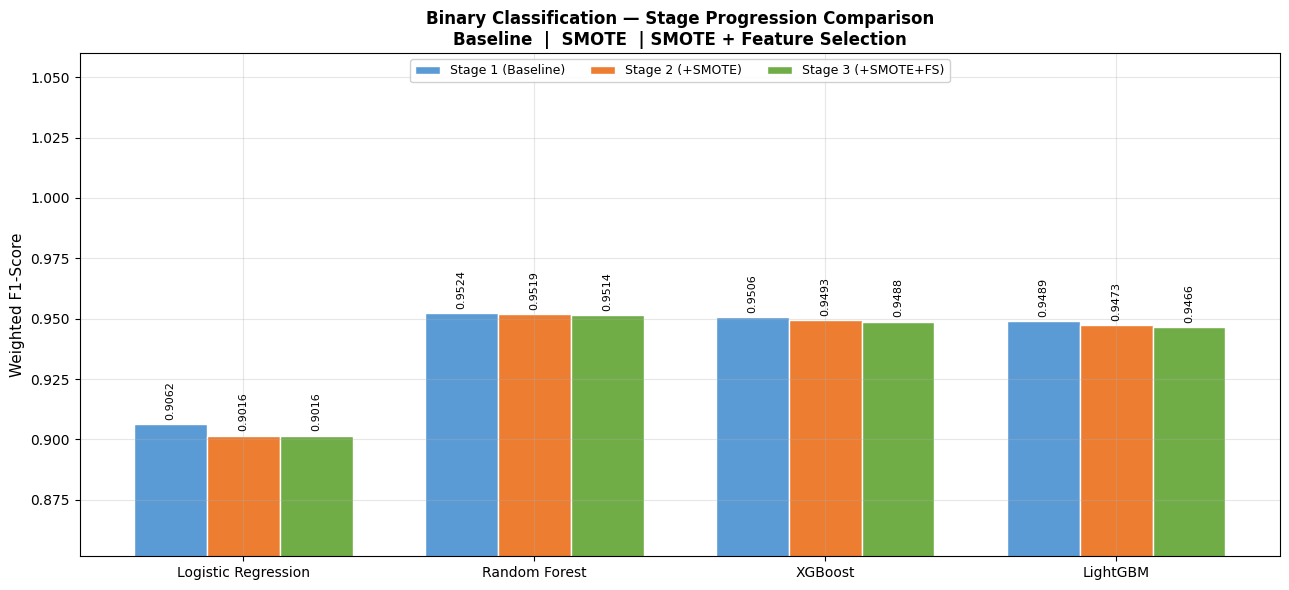


Binary F1-Score Progression (Weighted):
                     Stage 1\n(Baseline)  Stage 2\n(+SMOTE)  Stage 3\n(+SMOTE+FS)
Logistic Regression               0.9062             0.9016                0.9016
Random Forest                     0.9524             0.9519                0.9514
XGBoost                           0.9506             0.9493                0.9488
LightGBM                          0.9489             0.9473                0.9466

Best stage per model:
  Logistic Regression        =>  Stage 1 (Baseline)  (0.9062)
  Random Forest              =>  Stage 1 (Baseline)  (0.9524)
  XGBoost                    =>  Stage 1 (Baseline)  (0.9506)
  LightGBM                   =>  Stage 1 (Baseline)  (0.9489)

Delta F1  (Stage 3 - Stage 1):
  Logistic Regression        ▼  -0.0046
  Random Forest              ▼  -0.0010
  XGBoost                    ▼  -0.0018
  LightGBM                   ▼  -0.0023


In [44]:
# Stage Progression Comparison
# Compares binary classification F1-Score across all three pipeline stages.
# Requires: stage1_bin_results, stage2_bin_results, stage3_bin_results
model_names   = list(stage1_bin_results.keys())
stage_labels  = ['Stage 1\n(Baseline)', 'Stage 2\n(+SMOTE)', 'Stage 3\n(+SMOTE+FS)']
stage_results = [stage1_bin_results, stage2_bin_results, stage3_bin_results]
# Build comparison DataFrame (rows = models, columns = stages)
comparison_data = pd.DataFrame(
    {lbl: [r[m]['f1'] for m in model_names]
     for lbl, r in zip(stage_labels, stage_results)},
    index=model_names,
)
# Grouped bar chart
x       = np.arange(len(model_names))
width   = 0.25
offsets = [-width, 0, width]
colors  = ['#5B9BD5', '#ED7D31', '#70AD47']
fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, color) in enumerate(zip(comparison_data.columns, colors)):
    bars = ax.bar(x + offsets[i], comparison_data[col],
                  width=width, label=col.replace('\n', ' '),
                  color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Weighted F1-Score', fontsize=11)
ax.set_title(
    'Binary Classification — Stage Progression Comparison\n'
    'Baseline  |  SMOTE  | SMOTE + Feature Selection',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper center', ncol=3, framealpha=0.9)   # moved up, single row
ax.set_ylim(max(0, comparison_data.values.min() - 0.05), 1.06)      # extra headroom for the legend
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.show()

# Summary table
print("\nBinary F1-Score Progression (Weighted):")
print(comparison_data.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nBest stage per model:")
for m in model_names:
    best_col = comparison_data.loc[m].idxmax().replace('\n', ' ')
    best_val = comparison_data.loc[m].max()
    print(f"  {m:<25}  =>  {best_col}  ({best_val:.4f})")
print("\nDelta F1  (Stage 3 - Stage 1):")
for m in model_names:
    d = comparison_data.loc[m, 'Stage 3\n(+SMOTE+FS)'] - comparison_data.loc[m, 'Stage 1\n(Baseline)']
    arrow = "▲" if d >= 0 else "▼"
    print(f"  {m:<25}  {arrow}  {d:+.4f}")

### 6.3 - MindSpore Neural Network (MLP)

In [45]:
import mindspore
import mindspore.nn as nn
from mindspore import Tensor, set_seed, value_and_grad
from mindspore.common import dtype as mstype

set_seed(RANDOM_STATE)
mindspore.set_context(mode=mindspore.PYNATIVE_MODE, device_target='CPU')

class MLP(nn.Cell):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3):
        super().__init__()
        layers, in_d = [], input_dim
        for h in hidden_dims:
            layers += [nn.Dense(in_d, h), nn.ReLU(),
                       nn.Dropout(keep_prob=1.0 - dropout)]
            in_d = h
        layers.append(nn.Dense(in_d, output_dim))
        self.net = nn.SequentialCell(layers)
    def construct(self, x):
        return self.net(x)

def train_mlp(X_tr, y_tr, X_te, n_classes,
              hidden_dims=(256, 128, 64), lr=0.001, epochs=20, batch_size=2048):
    model     = MLP(X_tr.shape[1], list(hidden_dims), n_classes)
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = nn.Adam(model.trainable_params(), learning_rate=lr)
    def forward_fn(x, y):
        return loss_fn(model(x), y)
    grad_fn = value_and_grad(forward_fn, None, optimizer.parameters)
    model.set_train(True)
    n = X_tr.shape[0]
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        total_loss, n_batches = 0.0, 0
        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            loss, grads = grad_fn(Tensor(X_tr[b], mstype.float32),
                                  Tensor(y_tr[b], mstype.int32))
            optimizer(grads)
            total_loss += float(loss.asnumpy()); n_batches += 1
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs}  loss = {total_loss / n_batches:.4f}")
    model.set_train(False)
    preds = model(Tensor(X_te, mstype.float32)).asnumpy().argmax(axis=1)
    return model, preds

print("MindSpore loaded OK - version", mindspore.__version__)

[WARNING] ME(30268:7848,MainProcess):2026-05-30-14:15:54.745.000 [mindspore\context.py:1334] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


MindSpore loaded OK - version 2.8.0


In [46]:
if train_mlp is None:
    print("MindSpore not available — skipping binary MLP.")
else:
    # Prepare numpy arrays for MindSpore
    X_tr_np     = X_train_final.values.astype(np.float32)
    X_te_np     = X_test_final.values.astype(np.float32)
    y_tr_bin_np = y_train_bin_resampled.values.astype(np.int32)

    print("Training MindSpore MLP — Binary")
    t0 = time.time()
    ms_bin_model, y_pred_ms_bin = train_mlp(
        X_tr_np, y_tr_bin_np, X_te_np, n_classes=2
    )
    elapsed = time.time() - t0

    acc_ms_bin = accuracy_score(y_test_bin, y_pred_ms_bin)
    binary_results['MindSpore MLP'] = {
        'model' : ms_bin_model,
        'y_pred': y_pred_ms_bin,
        'acc'   : acc_ms_bin,
        'time'  : elapsed,
    }
    print(f"Accuracy : {acc_ms_bin:.4f}  ({elapsed:.1f}s)")

Training MindSpore MLP — Binary


[WARNING] ME(30268:7848,MainProcess):2026-05-30-14:15:54.989.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-14:15:54.993.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-14:15:54.996.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-14:15:55.270.00 [mindspore\common\_decorator.py:69] 'FusedSparseAdam' is deprecated from version 2.8.0 and will be removed in a future version.


  Epoch   5/20  loss = 0.1411
  Epoch  10/20  loss = 0.1360
  Epoch  15/20  loss = 0.1324
  Epoch  20/20  loss = 0.1310
Accuracy : 0.9435  (820.5s)


In [47]:
if train_mlp is None:
    print("MindSpore not available — skipping multiclass MLP.")
else:
    y_tr_multi_np = y_train_multi_enc.astype(np.int32)
    n_classes_ms  = len(le.classes_)

    print("Training MindSpore MLP — Multiclass")
    t0 = time.time()
    ms_multi_model, y_pred_ms_multi_enc = train_mlp(
        X_tr_np, y_tr_multi_np, X_te_np, n_classes=n_classes_ms
    )
    elapsed = time.time() - t0

    y_pred_ms_multi = le.inverse_transform(y_pred_ms_multi_enc)
    acc_ms_multi    = accuracy_score(y_test_multi, y_pred_ms_multi)

    multiclass_results['MindSpore MLP'] = {
        'model' : ms_multi_model,
        'y_pred': y_pred_ms_multi,
        'acc'   : acc_ms_multi,
        'time'  : elapsed,
    }
    print(f"Accuracy : {acc_ms_multi:.4f}  ({elapsed:.1f}s)")

[WARNING] ME(30268:7848,MainProcess):2026-05-30-14:29:35.422.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-14:29:35.424.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-14:29:35.426.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


Training MindSpore MLP — Multiclass
  Epoch   5/20  loss = 0.6062
  Epoch  10/20  loss = 0.5585
  Epoch  15/20  loss = 0.5478
  Epoch  20/20  loss = 0.5423
Accuracy : 0.8103  (800.0s)


---
## 7. Hyperparameter Optimization

`RandomizedSearchCV` (10 iterations, 3-fold CV) is applied to both **XGBoost** and **LightGBM**
for binary and multiclass tasks. The best estimator from each search is evaluated on the test set.

### 7.1 - Tuning XGBoost — Binary

In [48]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7, 9],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5],
}

xgb_bin = XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)

rs_binary = RandomizedSearchCV(
    xgb_bin,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs_binary.fit(X_train_final, y_train_bin_resampled)

print(f'Best params  : {rs_binary.best_params_}')
print(f'Best CV F1   : {rs_binary.best_score_:.4f}')

best_xgb_bin  = rs_binary.best_estimator_
y_pred_bin_tuned = best_xgb_bin.predict(X_test_final)
print(f'Test Accuracy: {accuracy_score(y_test_bin, y_pred_bin_tuned):.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params  : {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV F1   : 0.9493
Test Accuracy: 0.9533


### 7.2 - Tuning LightGBM — Binary

In [49]:
lgbm_param_dist = {
    'n_estimators'       : [100, 200, 300],
    'max_depth'          : [3, 5, 7, -1],
    'learning_rate'      : [0.01, 0.05, 0.1, 0.2],
    'subsample'          : [0.6, 0.8, 1.0],
    'colsample_bytree'   : [0.6, 0.8, 1.0],
    'num_leaves'         : [31, 63, 127],
    'min_child_samples'  : [20, 50, 100],
}

lgbm_bin = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

rs_lgbm_binary = RandomizedSearchCV(
    lgbm_bin,
    param_distributions=lgbm_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs_lgbm_binary.fit(X_train_final, y_train_bin_resampled)

print(f'Best params  : {rs_lgbm_binary.best_params_}')
print(f'Best CV F1   : {rs_lgbm_binary.best_score_:.4f}')

best_lgbm_bin     = rs_lgbm_binary.best_estimator_
y_pred_lgbm_bin   = best_lgbm_bin.predict(X_test_final)
print(f'Test Accuracy: {accuracy_score(y_test_bin, y_pred_lgbm_bin):.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params  : {'subsample': 0.6, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV F1   : 0.9498
Test Accuracy: 0.9533


### 7.3 - Tuning XGBoost — Multiclass

In [50]:
xgb_multi = XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=-1)

rs_multi = RandomizedSearchCV(
    xgb_multi,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs_multi.fit(X_train_final, y_train_multi_enc)

print(f'Best params  : {rs_multi.best_params_}')
print(f'Best CV F1   : {rs_multi.best_score_:.4f}')

best_xgb_multi       = rs_multi.best_estimator_
y_pred_multi_enc_tuned = best_xgb_multi.predict(X_test_final)
y_pred_multi_tuned   = le.inverse_transform(y_pred_multi_enc_tuned)
print(f'Test Accuracy: {accuracy_score(y_test_multi, y_pred_multi_tuned):.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params  : {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV F1   : 0.8207
Test Accuracy: 0.8291


### 7.4 - Tuning LightGBM — Multiclass

In [51]:
# LightGBM handles string labels directly — no encoding needed
lgbm_multi = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

rs_lgbm_multi = RandomizedSearchCV(
    lgbm_multi,
    param_distributions=lgbm_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rs_lgbm_multi.fit(X_train_final, y_train_multi_resampled)

print(f'Best params  : {rs_lgbm_multi.best_params_}')
print(f'Best CV F1   : {rs_lgbm_multi.best_score_:.4f}')

best_lgbm_multi   = rs_lgbm_multi.best_estimator_
y_pred_lgbm_multi = best_lgbm_multi.predict(X_test_final)
print(f'Test Accuracy: {accuracy_score(y_test_multi, y_pred_lgbm_multi):.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params  : {'subsample': 0.6, 'num_leaves': 127, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV F1   : 0.8154
Test Accuracy: 0.8225


### 7.5 - Tuning MindSpore MLP Architecture


In [52]:
if train_mlp is None:
    print("MindSpore not available — skipping binary MLP grid search.")
else:
    # Manual grid search — Binary
    configs = [
        {'hidden_dims': (128, 64),       'lr': 0.001},
        {'hidden_dims': (256, 128, 64),  'lr': 0.001},
        {'hidden_dims': (256, 128, 64),  'lr': 0.01},
        {'hidden_dims': (512, 256, 128), 'lr': 0.001},
    ]

    best_bin_acc, best_bin_cfg = 0, None

    print("Binary MLP grid search:")
    for cfg in configs:
        _, preds = train_mlp(X_tr_np, y_tr_bin_np, X_te_np, n_classes=2,
                             hidden_dims=cfg["hidden_dims"], lr=cfg["lr"], epochs=15)
        acc = accuracy_score(y_test_bin, preds)
        print(f"  hidden={cfg['hidden_dims']}  lr={cfg['lr']}  acc={acc:.4f}")
        if acc > best_bin_acc:
            best_bin_acc, best_bin_cfg = acc, cfg

    print(f"\nBest binary config : {best_bin_cfg}  (acc={best_bin_acc:.4f})")

    best_ms_bin_model, y_pred_ms_bin_tuned = train_mlp(
        X_tr_np, y_tr_bin_np, X_te_np, n_classes=2,
        hidden_dims=best_bin_cfg["hidden_dims"],
        lr=best_bin_cfg["lr"], epochs=20
    )
    print(f"Tuned Binary Accuracy : {accuracy_score(y_test_bin, y_pred_ms_bin_tuned):.4f}")

[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:23:43.349.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:23:43.355.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


Binary MLP grid search:
  Epoch   5/15  loss = 0.1434
  Epoch  10/15  loss = 0.1385


[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:28:48.438.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:28:48.441.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:28:48.442.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


  Epoch  15/15  loss = 0.1347
  hidden=(128, 64)  lr=0.001  acc=0.9402
  Epoch   5/15  loss = 0.1409
  Epoch  10/15  loss = 0.1359
  Epoch  15/15  loss = 0.1325


[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:37:43.436.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:37:43.438.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:37:43.440.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


  hidden=(256, 128, 64)  lr=0.001  acc=0.9429
  Epoch   5/15  loss = 0.1462
  Epoch  10/15  loss = 0.1430
  Epoch  15/15  loss = 0.1413


[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:47:01.688.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:47:01.690.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-15:47:01.691.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


  hidden=(256, 128, 64)  lr=0.01  acc=0.9366
  Epoch   5/15  loss = 0.1397
  Epoch  10/15  loss = 0.1343
  Epoch  15/15  loss = 0.1308


[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:03:27.336.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:03:27.338.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:03:27.339.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


  hidden=(512, 256, 128)  lr=0.001  acc=0.9438

Best binary config : {'hidden_dims': (512, 256, 128), 'lr': 0.001}  (acc=0.9438)
  Epoch   5/20  loss = 0.1394
  Epoch  10/20  loss = 0.1342
  Epoch  15/20  loss = 0.1305
  Epoch  20/20  loss = 0.1292
Tuned Binary Accuracy : 0.9441


In [53]:
if train_mlp is None:
    print("MindSpore not available — skipping multiclass MLP grid search.")
else:
    # Manual grid search — Multiclass
    best_multi_acc, best_multi_cfg = 0, None

    print("Multiclass MLP grid search:")
    for cfg in configs:
        _, preds_enc = train_mlp(X_tr_np, y_tr_multi_np, X_te_np, n_classes=n_classes_ms,
                                 hidden_dims=cfg["hidden_dims"], lr=cfg["lr"], epochs=15)
        preds = le.inverse_transform(preds_enc)
        acc   = accuracy_score(y_test_multi, preds)
        print(f"  hidden={cfg['hidden_dims']}  lr={cfg['lr']}  acc={acc:.4f}")
        if acc > best_multi_acc:
            best_multi_acc, best_multi_cfg = acc, cfg

    print(f"\nBest multiclass config : {best_multi_cfg}  (acc={best_multi_acc:.4f})")

    best_ms_multi_model, y_pred_ms_multi_enc_tuned = train_mlp(
        X_tr_np, y_tr_multi_np, X_te_np, n_classes=n_classes_ms,
        hidden_dims=best_multi_cfg["hidden_dims"],
        lr=best_multi_cfg["lr"], epochs=20
    )
    y_pred_ms_multi_tuned = le.inverse_transform(y_pred_ms_multi_enc_tuned)
    print(f"Tuned Multiclass Accuracy : {accuracy_score(y_test_multi, y_pred_ms_multi_tuned):.4f}")

[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:26:22.149.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:26:22.150.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


Multiclass MLP grid search:
  Epoch   5/15  loss = 0.6223
  Epoch  10/15  loss = 0.6079
  Epoch  15/15  loss = 0.5736


[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:32:08.990.00 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:32:08.101.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:32:08.103.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


  hidden=(128, 64)  lr=0.001  acc=0.8049
  Epoch   5/15  loss = 0.6055
  Epoch  10/15  loss = 0.5574
  Epoch  15/15  loss = 0.5478


[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:41:44.215.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:41:44.217.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:41:44.218.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


  hidden=(256, 128, 64)  lr=0.001  acc=0.8087
  Epoch   5/15  loss = 0.5903
  Epoch  10/15  loss = 0.5842
  Epoch  15/15  loss = 0.5854


[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:51:20.265.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:51:20.266.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-16:51:20.268.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


  hidden=(256, 128, 64)  lr=0.01  acc=0.7969
  Epoch   5/15  loss = 0.5707
  Epoch  10/15  loss = 0.5386
  Epoch  15/15  loss = 0.5291


[WARNING] ME(30268:7848,MainProcess):2026-05-30-17:07:34.799.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-17:07:34.803.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(30268:7848,MainProcess):2026-05-30-17:07:34.804.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


  hidden=(512, 256, 128)  lr=0.001  acc=0.8083

Best multiclass config : {'hidden_dims': (256, 128, 64), 'lr': 0.001}  (acc=0.8087)
  Epoch   5/20  loss = 0.6067
  Epoch  10/20  loss = 0.5583
  Epoch  15/20  loss = 0.5483
  Epoch  20/20  loss = 0.5426
Tuned Multiclass Accuracy : 0.8102


---
## 8. Model Evaluation and Comparison

Each model is evaluated using:
- Accuracy, Precision, Recall, F1-Score (weighted)
- Classification Report (per-class breakdown)
- Confusion Matrix
- Final summary comparison table

In [54]:
# Add all tuned models to result dictionaries
binary_results['XGBoost (Tuned)'] = {
    'model'  : best_xgb_bin,
    'y_pred' : y_pred_bin_tuned,
    'acc'    : accuracy_score(y_test_bin, y_pred_bin_tuned),
    'time'   : None,
}

binary_results['LightGBM (Tuned)'] = {
    'model'  : best_lgbm_bin,
    'y_pred' : y_pred_lgbm_bin,
    'acc'    : accuracy_score(y_test_bin, y_pred_lgbm_bin),
    'time'   : None,
}

if train_mlp is not None:
    binary_results['MindSpore MLP (Tuned)'] = {
        'model'  : best_ms_bin_model,
        'y_pred' : y_pred_ms_bin_tuned,
        'acc'    : accuracy_score(y_test_bin, y_pred_ms_bin_tuned),
        'time'   : None,
    }

multiclass_results['XGBoost (Tuned)'] = {
    'model'  : best_xgb_multi,
    'y_pred' : y_pred_multi_tuned,
    'acc'    : accuracy_score(y_test_multi, y_pred_multi_tuned),
    'time'   : None,
}

multiclass_results['LightGBM (Tuned)'] = {
    'model'  : best_lgbm_multi,
    'y_pred' : y_pred_lgbm_multi,
    'acc'    : accuracy_score(y_test_multi, y_pred_lgbm_multi),
    'time'   : None,
}

if train_mlp is not None:
    multiclass_results['MindSpore MLP (Tuned)'] = {
        'model'  : best_ms_multi_model,
        'y_pred' : y_pred_ms_multi_tuned,
        'acc'    : accuracy_score(y_test_multi, y_pred_ms_multi_tuned),
        'time'   : None,
    }

print('All tuned models added to results.')

All tuned models added to results.


### 8.1 - Binary Classification Evaluation

In [55]:
print('=' * 65)
print('BINARY - CLASSIFICATION REPORTS')
print('=' * 65)

sep = "-" * 40
for name, res in binary_results.items():
    print(f"\n{sep}")
    print(f"  {name}")
    print(sep)
    print(classification_report(y_test_bin, res['y_pred'],
                                target_names=['Benign', 'Attack']))

BINARY - CLASSIFICATION REPORTS

----------------------------------------
  Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

      Benign       0.65      0.35      0.46     40000
      Attack       0.93      0.98      0.95    347579

    accuracy                           0.91    387579
   macro avg       0.79      0.66      0.70    387579
weighted avg       0.90      0.91      0.90    387579


----------------------------------------
  Random Forest
----------------------------------------
              precision    recall  f1-score   support

      Benign       0.80      0.72      0.76     40000
      Attack       0.97      0.98      0.97    347579

    accuracy                           0.95    387579
   macro avg       0.89      0.85      0.87    387579
weighted avg       0.95      0.95      0.95    387579


----------------------------------------
  XGBoost
----------------------------------------
              pre

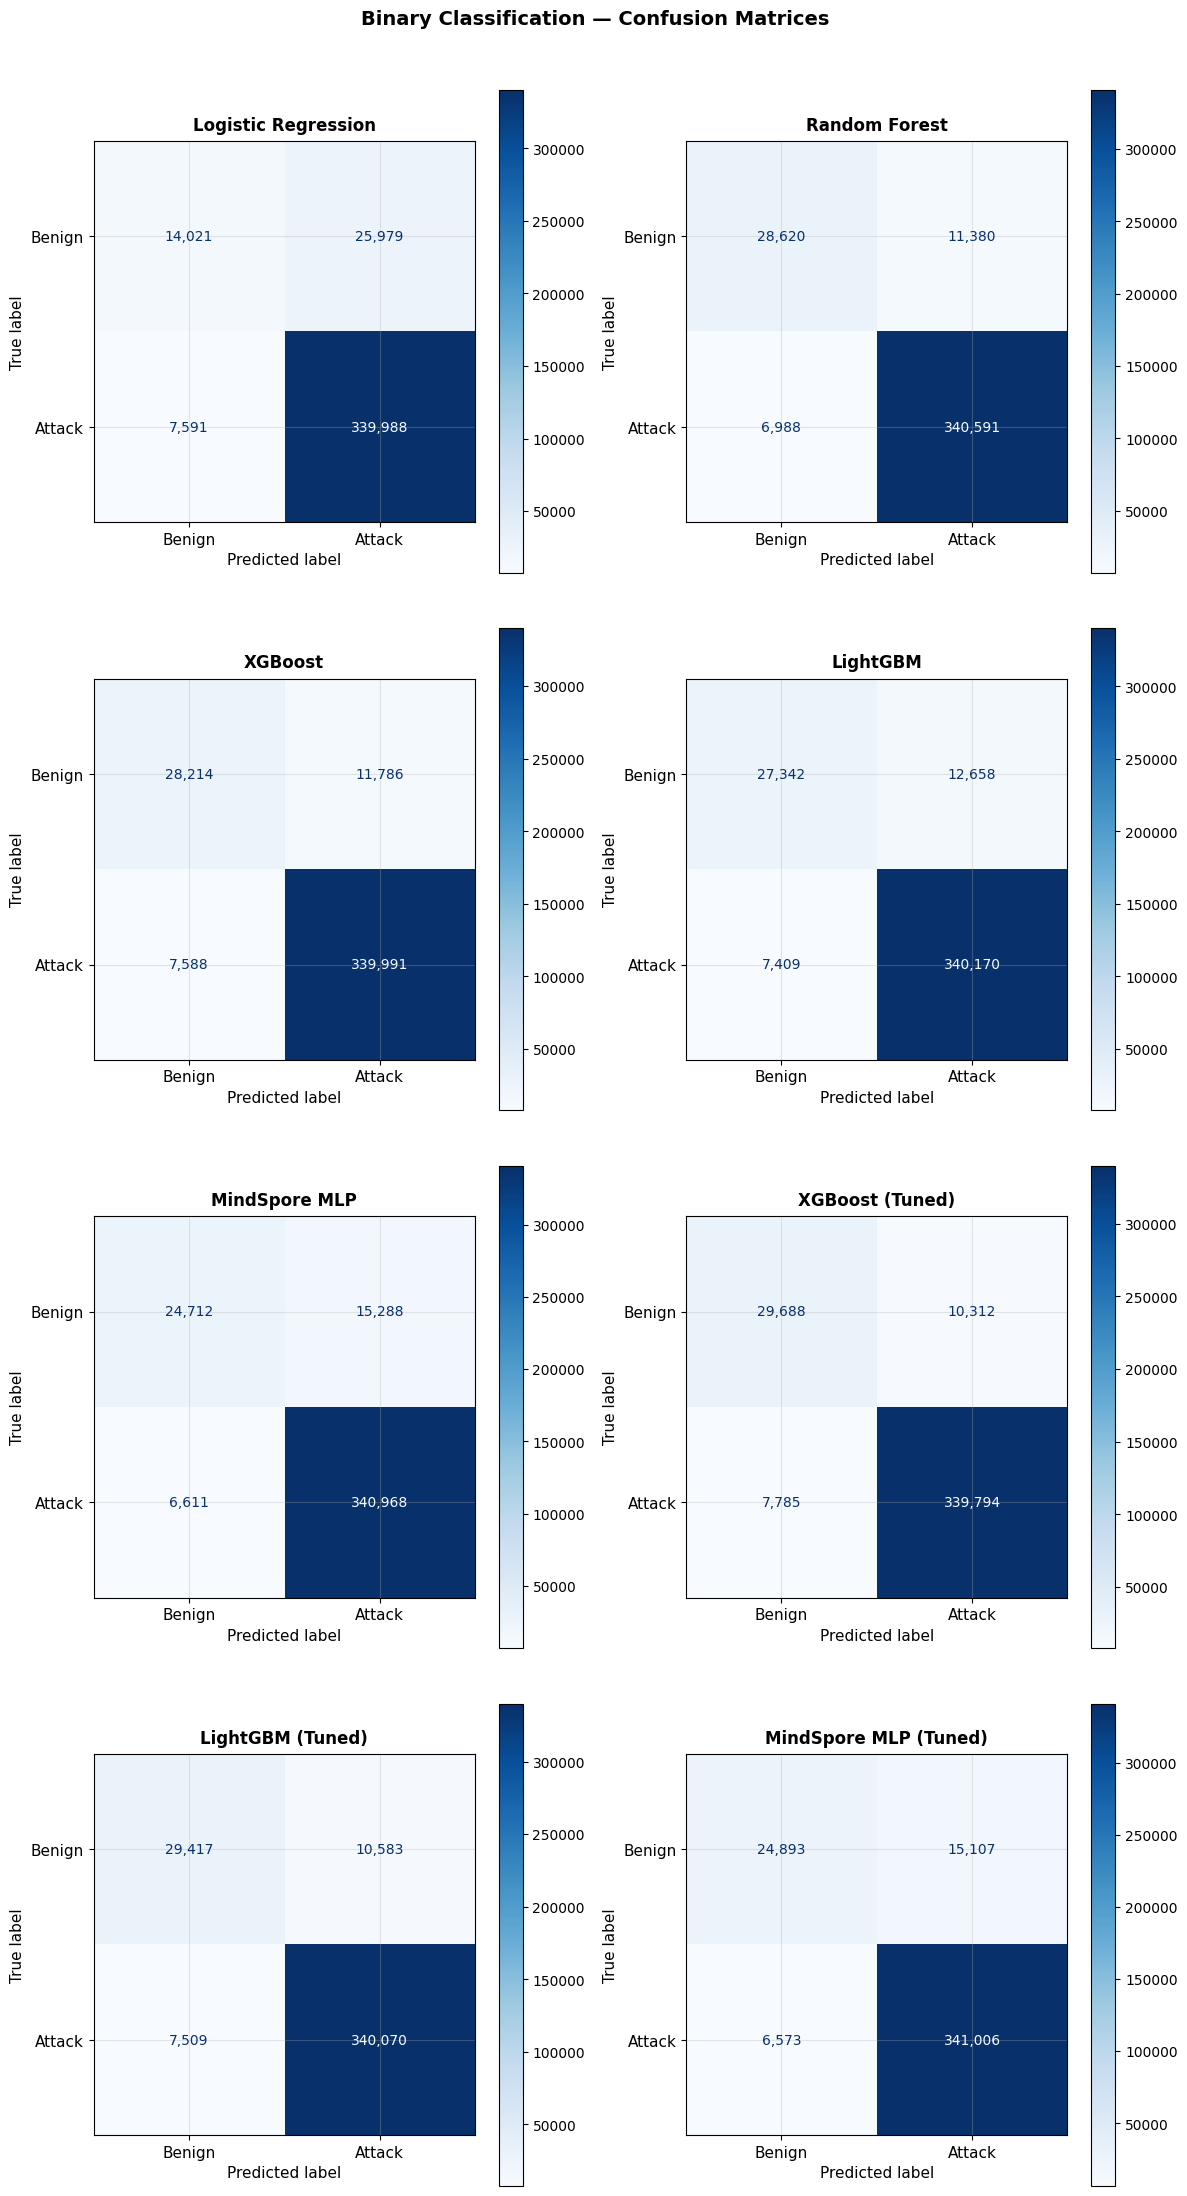

In [56]:
# Confusion matrices binary
import math as _math

n     = len(binary_results)
ncols = 2
nrows = _math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5.5 * nrows))
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, (name, res) in zip(axes_flat, binary_results.items()):
    cm = confusion_matrix(y_test_bin, res["y_pred"], labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Attack"])
    disp.plot(ax=ax, colorbar=True, xticks_rotation=0,
              values_format=",d", im_kw={"cmap": "Blues"})
    ax.set_title(name, fontsize=12, fontweight="bold", pad=8)
    ax.tick_params(axis="both", labelsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle("Binary Classification — Confusion Matrices", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 8.2 - Multiclass Classification Evaluation

In [57]:
print('=' * 65)
print('MULTICLASS - CLASSIFICATION REPORTS')
print('=' * 65)

sep = "-" * 40
for name, res in multiclass_results.items():
    print(f"\n{sep}")
    print(f"  {name}")
    print(sep)
    print(classification_report(y_test_multi, res['y_pred']))

MULTICLASS - CLASSIFICATION REPORTS

----------------------------------------
  Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

      Benign       0.55      0.59      0.57     40000
  BruteForce       0.19      0.16      0.17      2613
        DDoS       0.86      0.60      0.71    100000
         DoS       0.69      0.91      0.79    100000
     Malware       0.00      0.00      0.00       644
       Mirai       0.99      0.99      0.99     60000
       Recon       0.60      0.65      0.62     40000
    Spoofing       0.56      0.55      0.56     40000
   Uploading       0.00      0.00      0.00       250
   WebAttack       0.37      0.06      0.10      4072

    accuracy                           0.73    387579
   macro avg       0.48      0.45      0.45    387579
weighted avg       0.74      0.73      0.72    387579


----------------------------------------
  Random Forest
----------------------------------------
 

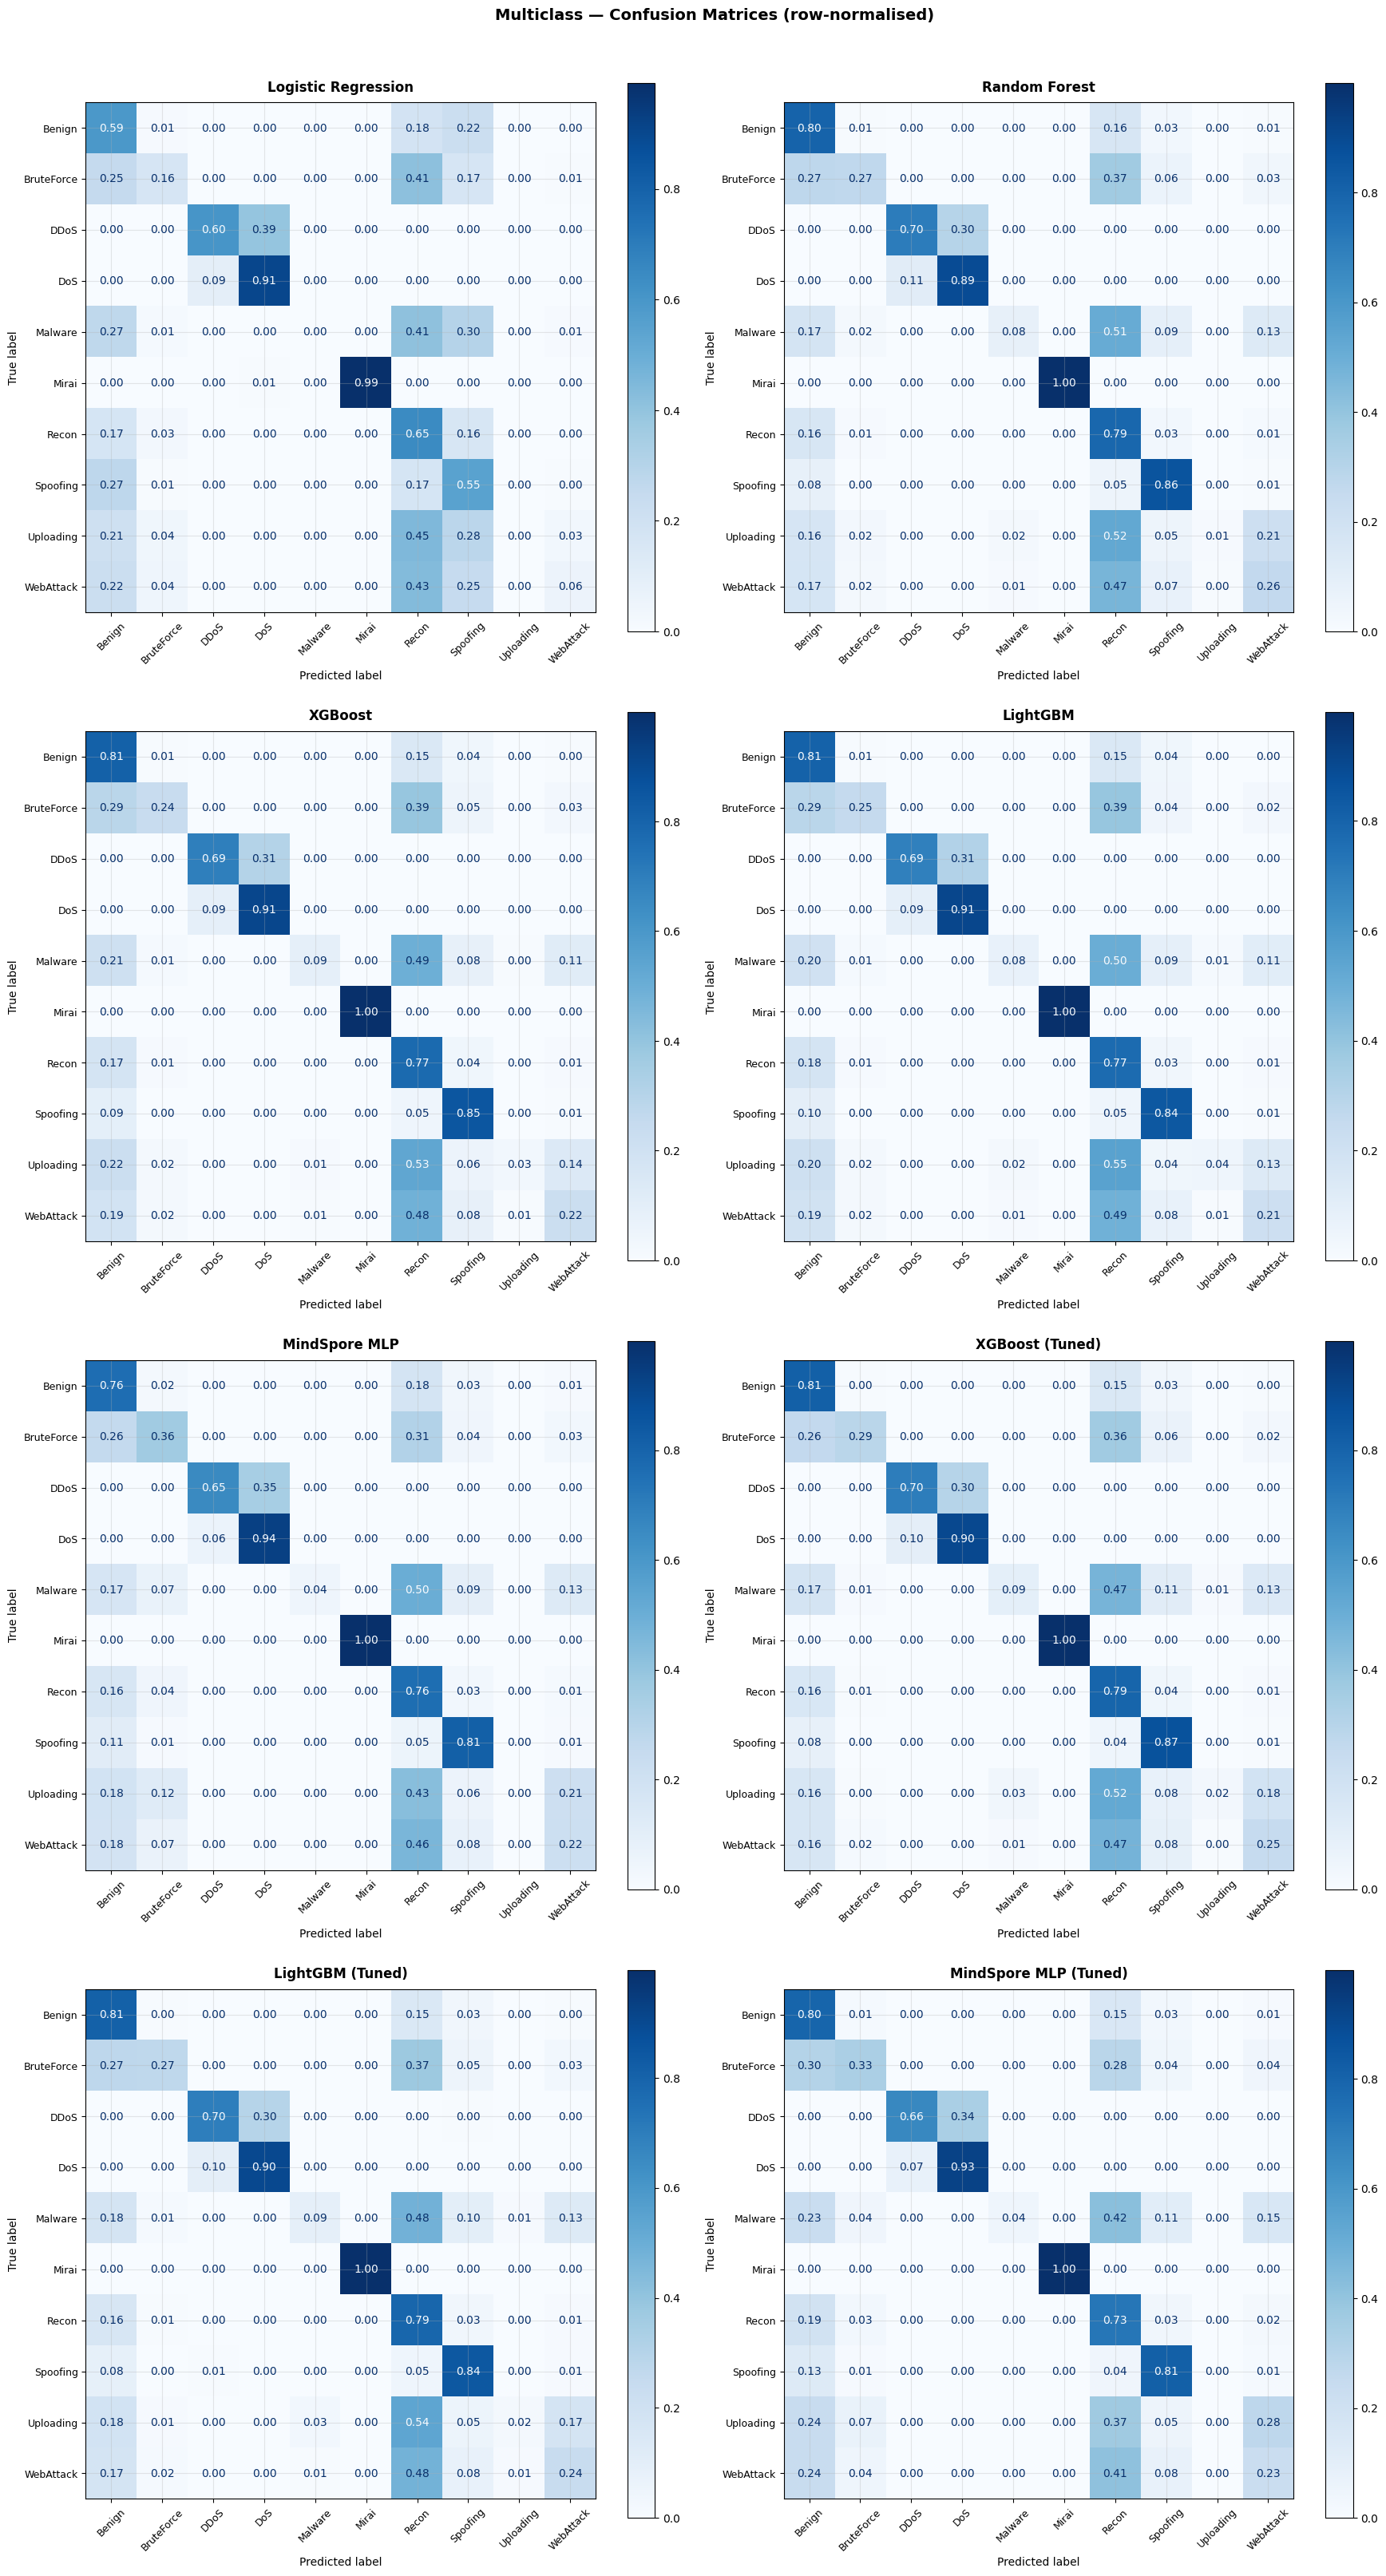

In [58]:
# Confusion matrices multiclass
import math as _math

class_labels = sorted(y_test_multi.unique())
n     = len(multiclass_results)
ncols = 2
nrows = _math.ceil(n / ncols)
cell_size = len(class_labels) * 0.7 + 1

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(18, cell_size * nrows))
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, (name, res) in zip(axes_flat, multiclass_results.items()):
    cm = confusion_matrix(y_test_multi, res["y_pred"],
                          labels=class_labels, normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=True, xticks_rotation=45,
              values_format=".2f", im_kw={"cmap": "Blues"})
    ax.set_title(name, fontsize=12, fontweight="bold", pad=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.set_xlabel("Predicted label", fontsize=10)
    ax.set_ylabel("True label", fontsize=10)

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle("Multiclass — Confusion Matrices (row-normalised)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 8.3 - Summary Comparison Table


────────────────────────────────────────────────────────────
BINARY SUMMARY
────────────────────────────────────────────────────────────
                       Accuracy  Precision  Recall  Weighted F1  Macro F1 Time (s)
Model                                                                             
Logistic Regression      0.9134     0.9001  0.9134       0.9016    0.7040 718.6000
Random Forest            0.9526     0.9508  0.9526       0.9514    0.8654  25.8000
XGBoost                  0.9500     0.9481  0.9500       0.9488    0.8584   2.2000
LightGBM                 0.9482     0.9458  0.9482       0.9466    0.8514   2.8000
MindSpore MLP            0.9435     0.9397  0.9435       0.9404    0.8309 820.5000
XGBoost (Tuned)          0.9533     0.9521  0.9533       0.9526    0.8702        -
LightGBM (Tuned)         0.9533     0.9519  0.9533       0.9525    0.8695        -
MindSpore MLP (Tuned)    0.9441     0.9404  0.9441       0.9411    0.8329        -

  Best by Macro F1 : XGBoost (T

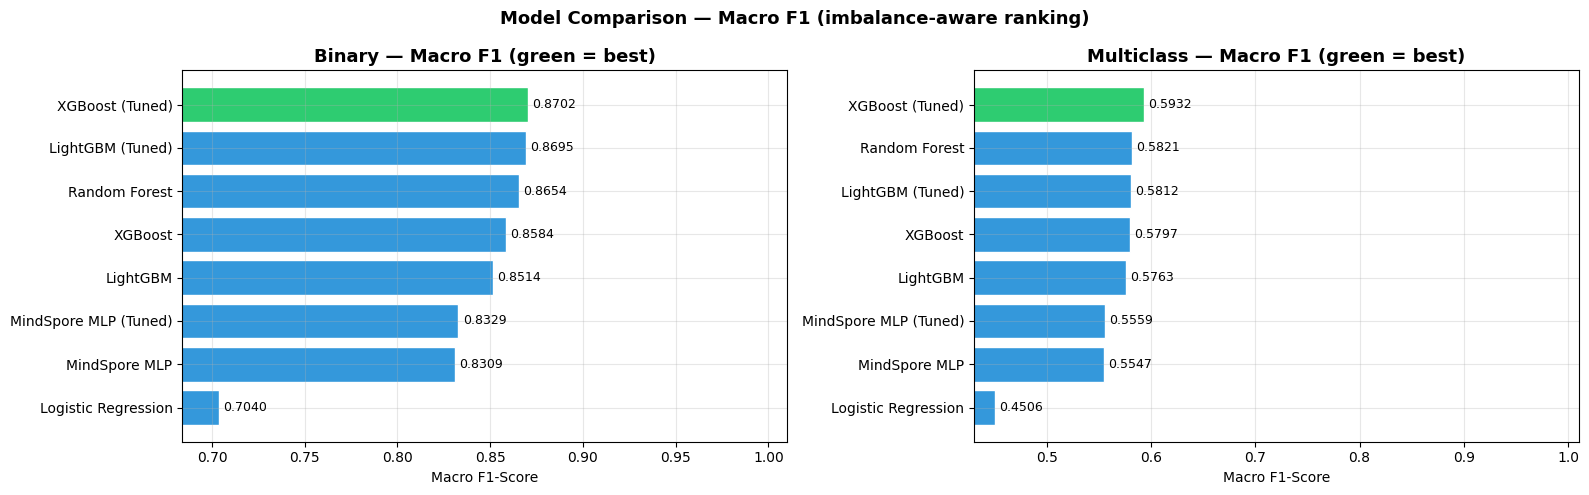

In [59]:
def summary_table(results, y_true, task_name):
    rows = []
    for name, res in results.items():
        y_pred = res['y_pred']
        rows.append({
            'Model'      : name,
            'Accuracy'   : round(accuracy_score(y_true, y_pred), 4),
            'Precision'  : round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
            'Recall'     : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
            'Weighted F1': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
            'Macro F1'   : round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
            'Time (s)'   : round(res['time'], 1) if res.get('time') is not None else '-',
        })
    df = pd.DataFrame(rows).set_index('Model')
    # Rank by Macro F1 — macro treats all classes equally
    best = df['Macro F1'].astype(float).idxmax()
    print(f"\n{'─'*60}\n{task_name}\n{'─'*60}")
    print(df.to_string())
    print(f"\n  Best by Macro F1 : {best}  ({df.loc[best, 'Macro F1']})")
    return df

df_binary     = summary_table(binary_results,     y_test_bin,   "BINARY SUMMARY")
df_multiclass = summary_table(multiclass_results, y_test_multi, "MULTICLASS SUMMARY")

# Side-by-side bar chart — Macro F1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for ax, df, title in [
    (ax1, df_binary,     'Binary'),
    (ax2, df_multiclass, 'Multiclass'),
]:
    scores = df['Macro F1'].astype(float).sort_values()
    colors = ['#2ecc71' if v == scores.max() else '#3498db' for v in scores]
    bars   = ax.barh(scores.index, scores.values, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_xlim(max(0, scores.min() - 0.02), 1.01)
    ax.set_title(f'{title} — Macro F1 (green = best)')
    ax.set_xlabel('Macro F1-Score')

plt.suptitle('Model Comparison — Macro F1 (imbalance-aware ranking)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.6 — SHAP Feature Attribution (XGBoost)


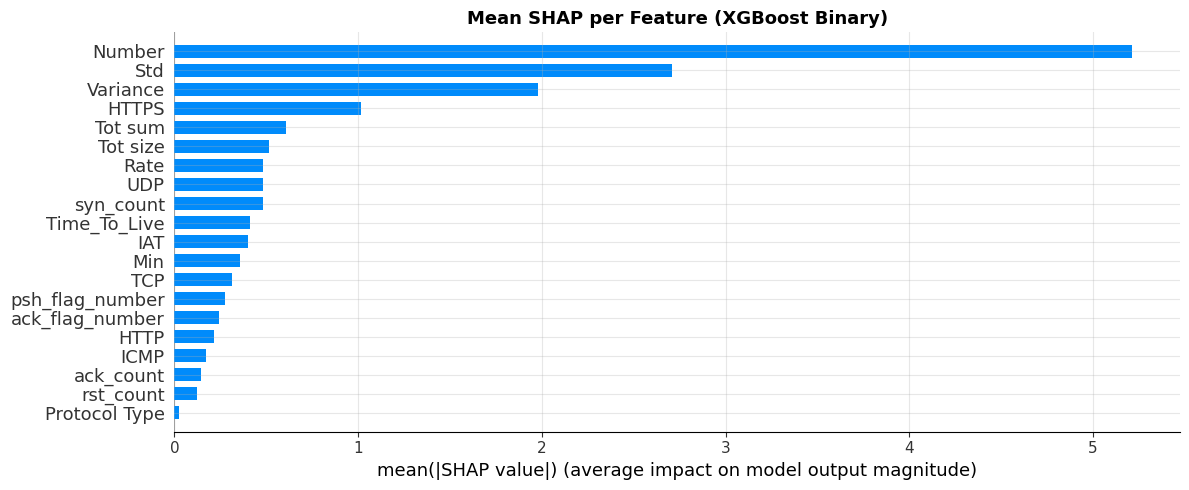

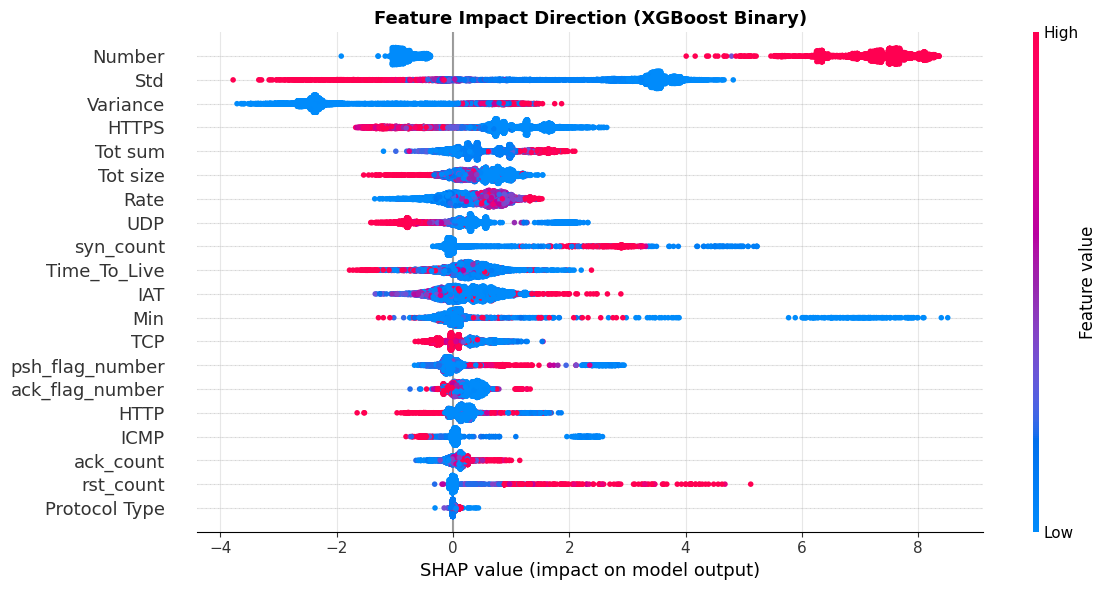

In [63]:
import shap

# Retrieve the trained binary XGBoost model
_xgb_bin = binary_results.get('XGBoost (Tuned)',
                              binary_results.get('XGBoost', {})).get('model')
if _xgb_bin is None:
    raise ValueError("XGBoost binary model not found in binary_results.")

# 5,000-sample subset for tractable SHAP computation
rng       = np.random.default_rng(RANDOM_STATE)
_shap_idx = rng.choice(len(X_test_final),
                       size=min(5000, len(X_test_final)), replace=False)
X_shap    = X_test_final.iloc[_shap_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(_xgb_bin)
shap_values = explainer.shap_values(X_shap)

# (a) Global summary bar plot — mean SHAP per feature
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  show=False, max_display=20, plot_size=(12, 5))
plt.gcf().axes[0].set_title('Mean SHAP per Feature (XGBoost Binary)',
                            fontweight='bold')
plt.tight_layout()
plt.show()

# (b) Beeswarm plot — direction and magnitude of each feature
shap.summary_plot(shap_values, X_shap, plot_type='dot',
                  show=False, max_display=20, plot_size=(12, 6))
plt.gcf().axes[0].set_title('Feature Impact Direction (XGBoost Binary)',
                            fontweight='bold')
plt.tight_layout()
plt.show()

### 9.7 — Inference Time and Memory Benchmark


              Model       Task  Latency (ms/sample)  Peak Mem (MB) Edge-suitable?
Logistic Regression     Binary               0.0014         0.2700             OK
      Random Forest     Binary               0.0963         5.5600             OK
            XGBoost     Binary               0.0018         0.1200             OK
           LightGBM     Binary               0.0027         1.6100             OK
    XGBoost (Tuned)     Binary               0.0022         0.1200             OK
   LightGBM (Tuned)     Binary               0.0017         1.6100             OK
Logistic Regression Multiclass               0.0009         1.5900             OK
      Random Forest Multiclass               0.1486        25.4000             OK
            XGBoost Multiclass               0.0050         0.4900             OK
           LightGBM Multiclass               0.0074         2.3000             OK
    XGBoost (Tuned) Multiclass               0.0083         0.4900             OK
   LightGBM (Tun

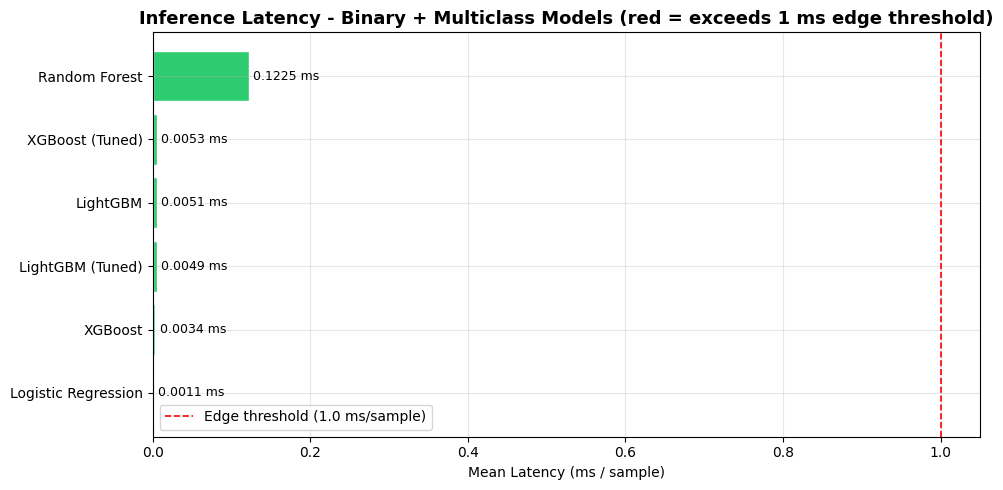

In [64]:
import tracemalloc
import time as _bench_time

_BATCH      = min(10_000, len(X_test_final))
_PROBE      = min(1_000,  len(X_test_final))
_X_bench    = X_test_final.iloc[:_BATCH]
_X_probe    = X_test_final.iloc[:_PROBE]
_LAT_THRESH = 1.0   # ms - flag above this for edge deployment

bench_rows = []

def _measure(name, model, X_probe, X_batch, le=None):
    times = []
    for _ in range(3):
        t0 = _bench_time.perf_counter()
        if le is not None:
            raw = model.predict(X_probe)
            try:
                le.inverse_transform(raw)
            except Exception:
                pass
        else:
            model.predict(X_probe)
        times.append((_bench_time.perf_counter() - t0) * 1000 / len(X_probe))
    lat_ms = round(sum(times) / 3, 4)

    tracemalloc.start()
    try:
        model.predict(X_batch)
    except Exception:
        pass
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mb = round(peak / 1024 / 1024, 2)

    flag = 'YES - offload to gateway' if lat_ms > _LAT_THRESH else 'OK'
    bench_rows.append({
        'Model'              : name,
        'Task'               : '-',
        'Latency (ms/sample)': lat_ms,
        'Peak Mem (MB)'      : peak_mb,
        'Edge-suitable?'     : flag,
    })

for name, res in binary_results.items():
    m = res.get('model')
    if m is None or not hasattr(m, 'predict'):
        continue
    _measure(name, m, _X_probe, _X_bench)
    bench_rows[-1]['Task'] = 'Binary'

for name, res in multiclass_results.items():
    m = res.get('model')
    if m is None or not hasattr(m, 'predict'):
        continue
    _measure(name, m, _X_probe, _X_bench, le=(le if 'XGBoost' in name else None))
    bench_rows[-1]['Task'] = 'Multiclass'

df_bench = pd.DataFrame(bench_rows)
print(df_bench.to_string(index=False))

_lat = df_bench.groupby('Model')['Latency (ms/sample)'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > _LAT_THRESH else '#2ecc71' for v in _lat.values]
bars = ax.barh(_lat.index, _lat.values, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.4f ms', padding=3, fontsize=9)
ax.axvline(_LAT_THRESH, color='red', linestyle='--', linewidth=1.2,
           label=f'Edge threshold ({_LAT_THRESH} ms/sample)')
ax.set_xlabel('Mean Latency (ms / sample)')
ax.set_title('Inference Latency - Binary + Multiclass Models'
             ' (red = exceeds 1 ms edge threshold)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Reinforcement Learning — DQN-Based Intrusion Detection

A Deep Q-Network (DQN) agent learns to classify network traffic as **Benign (0)** or **Attack (1)** through trial-and-error interaction with a simulated network environment.

**Reward structure:**
- Correct classification: **+1.0**
- False negative (missed attack): **-2.0** (higher penalty ,security-critical)
- False positive (benign labelled attack): **-1.0**

The agent uses **experience replay** and a **target network** for stable training.


In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random as _random


class IDSEnv:
    def __init__(self, X, y):
        # Convert DataFrame -> numpy so integer row-indexing works
        self.X = (X.values if hasattr(X, 'values') else X).astype(np.float32)
        self.y = (y.values if hasattr(y, 'values') else y).astype(int)
        self.n = len(self.X)
        self._idx = 0

    def reset(self):
        self._idx = np.random.randint(0, self.n)
        return self.X[self._idx]

    def step(self, action):
        true_label = self.y[self._idx]
        if action == true_label:
            reward = 1.0
        elif action == 0 and true_label == 1:
            reward = -2.0   # false negative: missed attack, higher penalty
        else:
            reward = -1.0   # false positive
        self._idx = (self._idx + 1) % self.n
        next_state = self.X[self._idx]
        done = False        # continuous environment; episode length set by STEPS_PER_EP
        return next_state, reward, done, {}


class DQNet(nn.Module):
    def __init__(self, input_dim, n_actions=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    def __init__(self, state_dim, n_actions=2, lr=1e-3,
                 gamma=0.95, eps=1.0, eps_min=0.05, eps_decay=0.995,
                 buffer_size=10_000, batch_size=64):
        self.n_actions  = n_actions
        self.gamma      = gamma
        self.epsilon    = eps
        self.eps_min    = eps_min
        self.eps_decay  = eps_decay
        self.batch_size = batch_size
        self.memory     = deque(maxlen=buffer_size)
        self.device     = torch.device('cpu')
        self.policy_net = DQNet(state_dim, n_actions).to(self.device)
        self.target_net = DQNet(state_dim, n_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        self.optimizer  = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn    = nn.SmoothL1Loss()

    def act(self, state):
        if _random.random() < self.epsilon:
            return _random.randint(0, self.n_actions - 1)
        with torch.no_grad():
            t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            return self.policy_net(t).argmax(dim=1).item()

    def remember(self, s, a, r, s2, done):
        self.memory.append((s, a, r, s2, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        batch = _random.sample(self.memory, self.batch_size)
        s, a, r, s2, d = zip(*batch)
        S  = torch.FloatTensor(np.array(s)).to(self.device)
        A  = torch.LongTensor(a).unsqueeze(1).to(self.device)
        R  = torch.FloatTensor(r).unsqueeze(1).to(self.device)
        S2 = torch.FloatTensor(np.array(s2)).to(self.device)
        D  = torch.FloatTensor(d).unsqueeze(1).to(self.device)
        Q        = self.policy_net(S).gather(1, A)
        Q_next   = self.target_net(S2).max(1, keepdim=True)[0].detach()
        Q_target = R + self.gamma * Q_next * (1 - D)
        loss = self.loss_fn(Q, Q_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.epsilon > self.eps_min:
            self.epsilon *= self.eps_decay
        return loss.item()

    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())


_rl_available = True
print(f"PyTorch {torch.__version__} loaded — DQN ready.")

PyTorch 2.9.1+cpu loaded — DQN ready.


  Episode 01/10 | Avg Reward: +0.583 | Avg Loss: 0.1229 | Epsilon: 0.0499
  Episode 02/10 | Avg Reward: +0.761 | Avg Loss: 0.1444 | Epsilon: 0.0499
  Episode 03/10 | Avg Reward: +0.757 | Avg Loss: 0.1366 | Epsilon: 0.0499
  Episode 04/10 | Avg Reward: +0.781 | Avg Loss: 0.1251 | Epsilon: 0.0499
  Episode 05/10 | Avg Reward: +0.788 | Avg Loss: 0.1197 | Epsilon: 0.0499
  Episode 06/10 | Avg Reward: +0.755 | Avg Loss: 0.1375 | Epsilon: 0.0499
  Episode 07/10 | Avg Reward: +0.790 | Avg Loss: 0.1374 | Epsilon: 0.0499
  Episode 08/10 | Avg Reward: +0.780 | Avg Loss: 0.1390 | Epsilon: 0.0499
  Episode 09/10 | Avg Reward: +0.777 | Avg Loss: 0.1325 | Epsilon: 0.0499
  Episode 10/10 | Avg Reward: +0.780 | Avg Loss: 0.1482 | Epsilon: 0.0499

Training complete in 36.2s


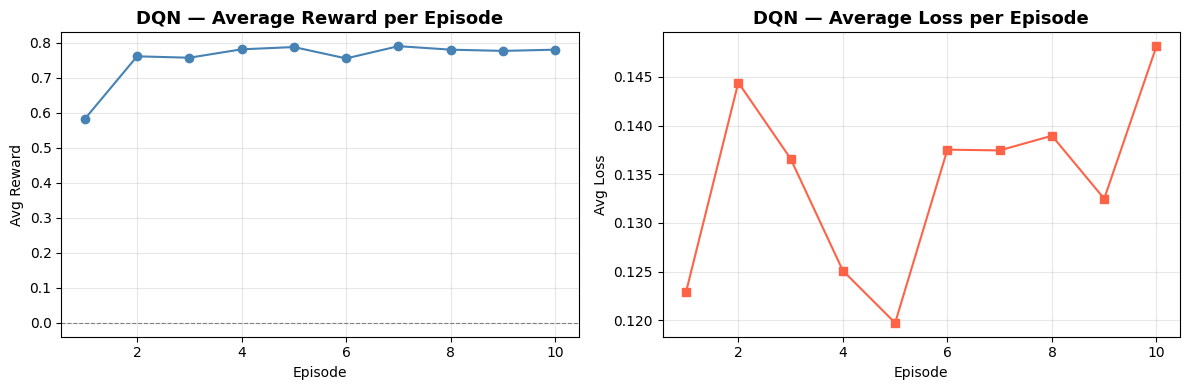


=== DQN Test Evaluation ===
              precision    recall  f1-score   support

      Benign       0.77      0.50      0.60     40000
      Attack       0.94      0.98      0.96    347579

    accuracy                           0.93    387579
   macro avg       0.86      0.74      0.78    387579
weighted avg       0.93      0.93      0.93    387579



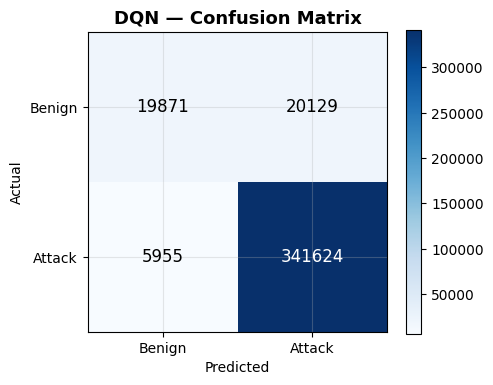


=== DQN vs Stage-3 Supervised Models (Weighted F1) ===


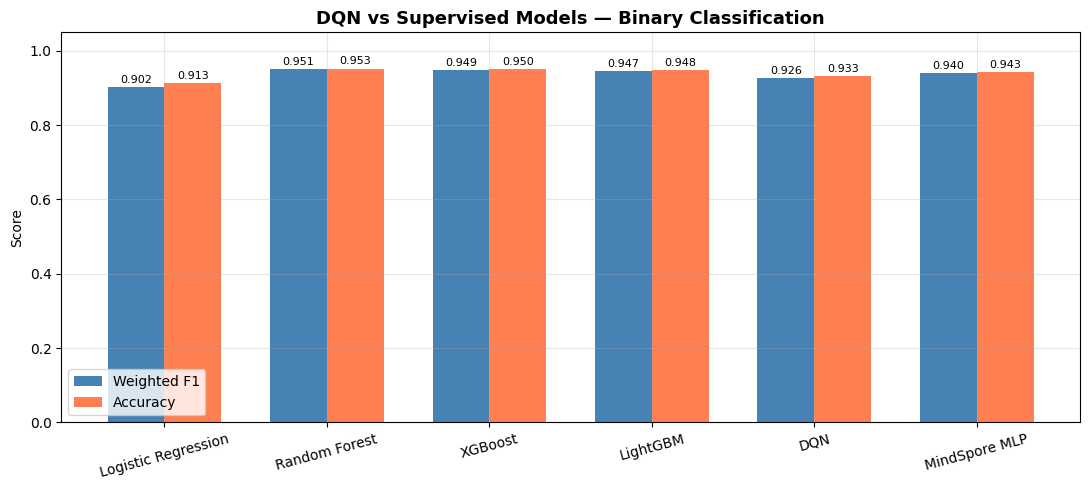

,Model,F1,Accuracy
0,Random Forest,0.9514,0.9526
1,XGBoost,0.9488,0.9500
2,LightGBM,0.9466,0.9482
3,MindSpore MLP,0.9404,0.9435
4,DQN,0.9261,0.9327
5,Logistic Regression,0.9016,0.9134


In [69]:
_rl_available = globals().get("_rl_available", False)
if _rl_available:
    import time as _time

    # Setup
    _Xdf = X_test_final if 'X_test_final' in dir() else X_test_scaled
    X_rl = (_Xdf.values if hasattr(_Xdf, 'values') else _Xdf).astype(np.float32)
    y_rl = (y_test_bin.values if hasattr(y_test_bin, 'values') else y_test_bin).astype(int)
    env   = IDSEnv(X_rl, y_rl)
    agent = DQNAgent(state_dim=X_rl.shape[1])

    N_EPISODES    = 10
    STEPS_PER_EP  = 2000
    TARGET_UPDATE = 500
    ep_rewards, ep_losses = [], []

    # Training
    t0 = _time.time()
    for ep in range(N_EPISODES):
        state = env.reset()
        total_r = total_l = 0.0
        for step in range(STEPS_PER_EP):
            action = agent.act(state)
            next_state, reward, done, _ = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            total_r += reward
            total_l += agent.replay()
            state = next_state
            if step % TARGET_UPDATE == 0:
                agent.update_target()
        ep_rewards.append(total_r / STEPS_PER_EP)
        ep_losses.append(total_l  / STEPS_PER_EP)
        print(f"  Episode {ep+1:02d}/{N_EPISODES} | "
              f"Avg Reward: {ep_rewards[-1]:+.3f} | "
              f"Avg Loss: {ep_losses[-1]:.4f} | "
              f"Epsilon: {agent.epsilon:.4f}")
    print(f"\nTraining complete in {_time.time() - t0:.1f}s")

    # Reward / loss curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(range(1, N_EPISODES + 1), ep_rewards, marker='o', color='steelblue')
    axes[0].set_title('DQN — Average Reward per Episode')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Avg Reward')
    axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
    axes[1].plot(range(1, N_EPISODES + 1), ep_losses, marker='s', color='tomato')
    axes[1].set_title('DQN — Average Loss per Episode')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Avg Loss')
    plt.tight_layout()
    plt.show()

    # Evaluation
    agent.epsilon = 0.0
    y_pred_dqn = np.array([agent.act(X_rl[i]) for i in range(len(X_rl))])
    from sklearn.metrics import (classification_report, confusion_matrix,
                                 f1_score, accuracy_score)
    dqn_acc = accuracy_score(y_rl, y_pred_dqn)
    dqn_f1  = f1_score(y_rl, y_pred_dqn, average='weighted')
    print('\n=== DQN Test Evaluation ===')
    print(classification_report(y_rl, y_pred_dqn,
                                 target_names=['Benign', 'Attack']))

    # Confusion matrix
    cm = confusion_matrix(y_rl, y_pred_dqn)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benign', 'Attack'])
    ax.set_yticklabels(['Benign', 'Attack'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=12,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title('DQN — Confusion Matrix')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    # --- MindSpore MLP binary metrics (added to comparison) ----------------
    # Auto-detect your MindSpore binary predictions. If your variable has a
    # different name, set _y_pred_ms manually, e.g. _y_pred_ms = y_pred_ms_bin
    _g = globals()
    _ms_f1 = _ms_acc = None
    _ms_pred_candidates = ['y_pred_ms_bin', 'y_pred_ms_binary',
                           'y_pred_ms_bin_tuned', 'ms_bin_preds']
    _y_pred_ms = next((_g[v] for v in _ms_pred_candidates if v in _g), None)

    if _y_pred_ms is not None:
        _y_pred_ms = np.asarray(_y_pred_ms).ravel()
        if len(_y_pred_ms) == len(y_rl):
            _ms_f1  = f1_score(y_rl, _y_pred_ms, average='weighted')
            _ms_acc = accuracy_score(y_rl, _y_pred_ms)
        else:
            print(f"MindSpore preds length ({len(_y_pred_ms)}) != test set "
                  f"({len(y_rl)}) — skipping MindSpore in comparison.")
    elif 'binary_results' in _g and isinstance(binary_results, dict):
        # Fallback: pull a stored MindSpore/MLP entry if you saved one
        _ms_key = next((k for k in binary_results
                        if 'mindspore' in k.lower() or 'mlp' in k.lower()), None)
        if _ms_key:
            _ms_f1  = binary_results[_ms_key].get('f1')
            _ms_acc = binary_results[_ms_key].get('acc')

    if _ms_f1 is None:
        print("MindSpore MLP result not found — set _y_pred_ms (its binary "
              "predictions) or add it to binary_results to include it.")

    # Comparison vs Stage-3
    print('\n=== DQN vs Stage-3 Supervised Models (Weighted F1) ===')
    if 'stage3_bin_results' in dir() and stage3_bin_results:
        comp_names = list(stage3_bin_results.keys()) + ['DQN']
        comp_f1    = [stage3_bin_results[m]['f1']  for m in stage3_bin_results] + [dqn_f1]
        comp_acc   = [stage3_bin_results[m]['acc'] for m in stage3_bin_results] + [dqn_acc]

        # Append MindSpore MLP if its metrics were found
        if _ms_f1 is not None:
            comp_names.append('MindSpore MLP')
            comp_f1.append(_ms_f1)
            comp_acc.append(_ms_acc)

        x = np.arange(len(comp_names))
        w = 0.35
        fig, ax = plt.subplots(figsize=(11, 5))
        b1 = ax.bar(x - w / 2, comp_f1,  w, label='Weighted F1', color='steelblue')
        b2 = ax.bar(x + w / 2, comp_acc, w, label='Accuracy',    color='coral')
        ax.set_xticks(x)
        ax.set_xticklabels(comp_names, rotation=15)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score')
        ax.set_title('DQN vs Supervised Models — Binary Classification')
        ax.legend()
        for bar in b1:
            ax.annotate(f"{bar.get_height():.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', fontsize=8)
        for bar in b2:
            ax.annotate(f"{bar.get_height():.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', fontsize=8)
        plt.tight_layout()
        plt.show()
        df_comp = pd.DataFrame({'Model': comp_names,
                                'F1': comp_f1,
                                'Accuracy': comp_acc})
        df_comp = df_comp.sort_values('F1', ascending=False).reset_index(drop=True)
        display(df_comp)
    else:
        print(f"DQN — Accuracy: {dqn_acc:.4f} | Weighted F1: {dqn_f1:.4f}")
        if _ms_f1 is not None:
            print(f"MindSpore MLP — Accuracy: {_ms_acc:.4f} | Weighted F1: {_ms_f1:.4f}")